In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
import math
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from tensorflow.keras import layers, models

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load data
data_path = '/content/drive/MyDrive/dataset'
file_path = f'{data_path}/Galaxy10_DECals.h5'
with h5py.File(file_path, 'r') as f:
    images = np.array(f['images'])
    labels = np.array(f['ans'])

    redshift = np.array(f['redshift'])


print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

print(f"Redshift shape: {redshift.shape}")

In [ ]:
# 1.a.: Inspect redshift values
print("Checking redshift for invalid values...")
print(f"images min: {images.min():.4f}, max: {images.max():.4f}")
print(f"Nan labels: {np.isnan(labels).sum():.4f}, Unique Classes: {np.unique(labels)}")

print(f"NaN count: {np.isnan(redshift).sum()}, Inf count: {np.isinf(redshift).sum()}")
print(f"Redshift min: {np.min(redshift):.4f}, max: {np.max(redshift):.4f}")


Checking redshift for invalid values...
images min: 0.0000, max: 255.0000
Nan labels: 0.0000, Unique Classes: [0 1 2 3 4 5 6 7 8 9]
NaN count: 92, Inf count: 0
Redshift min: nan, max: nan


In [ ]:
class_names = ['Disturbed', 'Merging', 'Round Smooth', 'In-between Round Smooth',
               'Cigar Shaped Smooth', 'Barred Spiral', 'Unbarred Tight Spiral','Unbarred Loose Spiral', 'Edge-on without Bulge', 'Edge-on with Bulge']

num_classes = len(class_names)

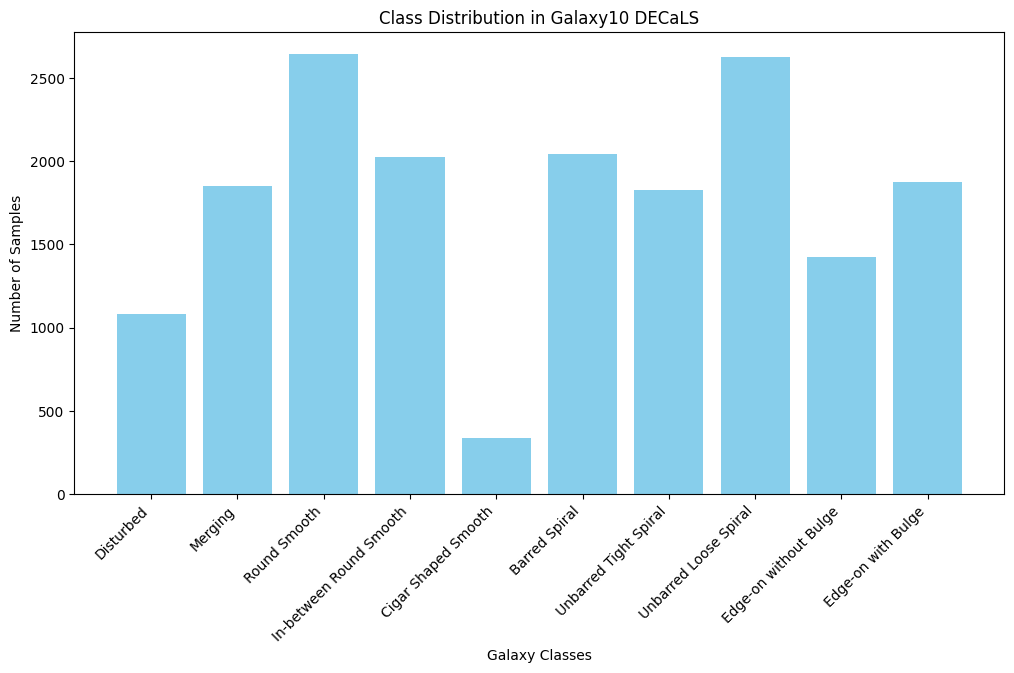

Class Distribution:
Disturbed: 1081
Merging: 1853
Round Smooth: 2645
In-between Round Smooth: 2027
Cigar Shaped Smooth: 334
Barred Spiral: 2043
Unbarred Tight Spiral: 1829
Unbarred Loose Spiral: 2628
Edge-on without Bulge: 1423
Edge-on with Bulge: 1873


In [ ]:
# distributio of galaxies
# 1.b.Class Distribution( class imbalance)
label_counts = Counter(labels)
plt.figure(figsize=(12, 6))
plt.bar(class_names, [label_counts.get(i, 0) for i in range(10)], color='skyblue')
plt.xlabel('Galaxy Classes')
plt.ylabel('Number of Samples')
plt.title('Class Distribution in Galaxy10 DECaLS')
plt.xticks(rotation=45, ha='right')
#plt.savefig(f'{data_path}/class_distribution_decals.png')
plt.show()


print("Class Distribution:")
for i, name in enumerate(class_names):
    print(f"{name}: {label_counts.get(i, 0)}")

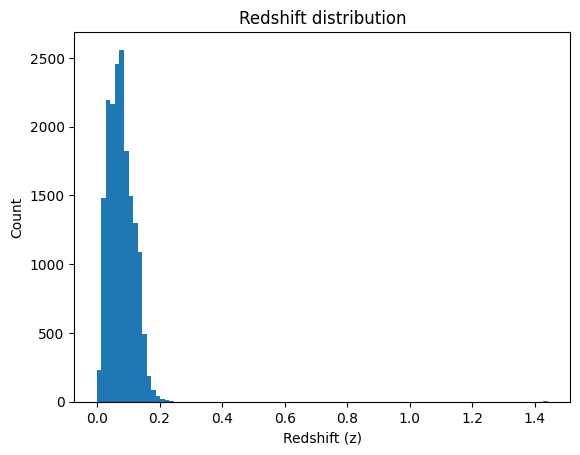

In [ ]:
#1.c.Resdhift distribution
plt.hist(redshift, bins=100)
plt.xlabel("Redshift (z)")
plt.ylabel("Count")
plt.title("Redshift distribution")
plt.show()

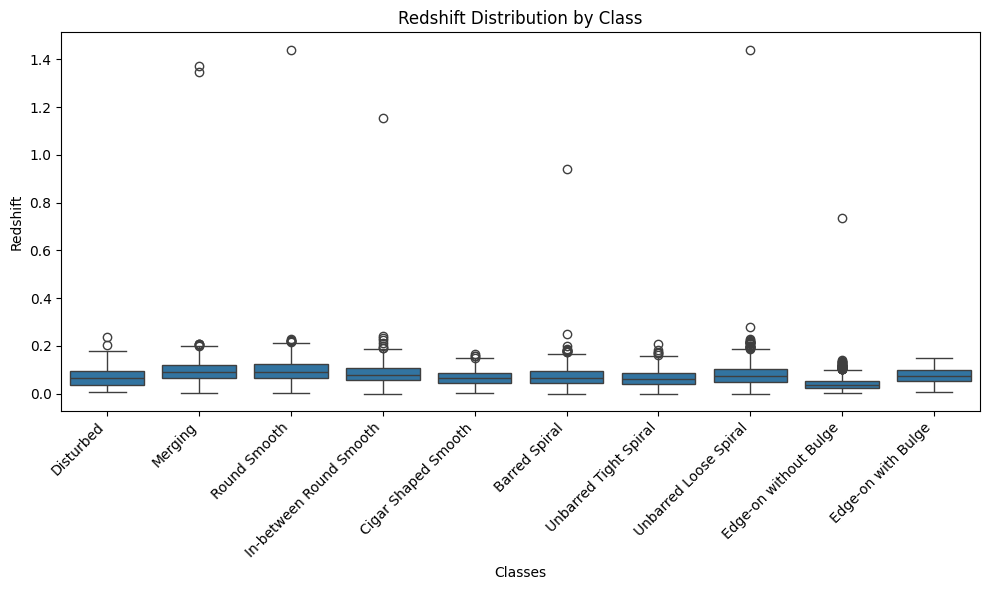

In [ ]:
# 1.d.Redshift Distribution by Class
plt.figure(figsize=(10, 6))
# Map the integer labels to class names for the x-axis using the labels
x_labels = [class_names[label] for label in labels]
# Use the redshift_raw
sns.boxplot(x=x_labels, y=redshift.flatten(),  legend=False )
plt.xlabel('Classes')
plt.ylabel('Redshift')
plt.title('Redshift Distribution by Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout() # Adjust layout to prevent labels overlapping
plt.show()

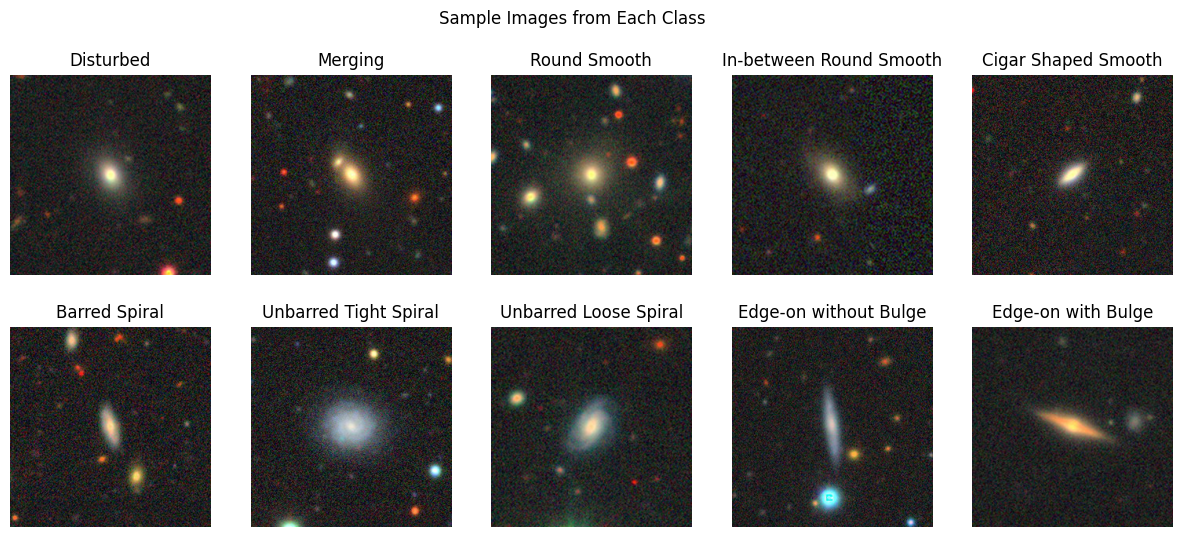

In [ ]:
# 1.e.Sample images from ecah Classes(raw samples)
plt.figure(figsize=(15, 6))
for i in range(10):
    idx = np.random.choice(np.where(labels== i)[0])
    plt.subplot(2, 5, i+1)
    img = images[idx]
    plt.imshow(img, vmin=0, vmax=1)
    plt.title(class_names[i])
    plt.axis('off')
plt.suptitle('Sample Images from Each Class')
plt.show()

In [ ]:
#step 2: Data cleaning process
# 2.a.Copy to avoid modifying original
redshift_clean = redshift.copy()

#a: Drop rows with NaN values
valid_mask = ~np.isnan(redshift_clean)
print(f"Removing {len(redshift_clean) - valid_mask.sum()} NaN rows")
redshift_clean = redshift_clean[valid_mask]
images_clean = images[valid_mask]
labels_clean = labels[valid_mask]


print("After cleaning:")
print("NaN count:", np.isnan(redshift_clean).sum())
print("Inf count:", np.isinf(redshift_clean).sum())
print("Min of redshift:", redshift_clean.min(), "Max of redshift:", redshift_clean.max())
print("Mean of redshift:", redshift_clean.mean(), "Std of redshift:", redshift_clean.std())

print(f"redshift_clean shape: {redshift_clean.shape}")
print(f"images_clean shape: {images_clean.shape}")
print(f"labels_clean shape: {labels_clean.shape}")

Removing 92 NaN rows
After cleaning:
NaN count: 0
Inf count: 0
Min of redshift: -0.0001244358 Max of redshift: 1.441647
Mean of redshift: 0.07750321706732066 Std of redshift: 0.04469131978755938
redshift_clean shape: (17644,)
images_clean shape: (17644, 256, 256, 3)
labels_clean shape: (17644,)


In [ ]:
# 2.b.FILTER: 0.0 < z < 1.5 (remove stars & high-z)
z_mask = (redshift_clean > 0.01) & (redshift_clean < 0.4)
print(f"Removing {len(redshift_clean) - z_mask.sum()} outlier z values")

redshift_clean = redshift_clean[z_mask]
images_clean = images_clean[z_mask]
labels_clean = labels_clean[z_mask]

print(f"redshift_clean shape: {redshift_clean.shape}")
print(f"images_clean shape: {images_clean.shape}")
print(f"labels_clean shape: {labels_clean.shape}")

Removing 88 outlier z values
redshift_clean shape: (17556,)
images_clean shape: (17556, 256, 256, 3)
labels_clean shape: (17556,)


In [ ]:
# Final stats after cleaning
print("\nAfter CORRECT cleaning:")
print("NaN count:", np.isnan(redshift_clean).sum())
print("Inf count:", np.isinf(redshift_clean).sum())
print("Min of redshift:", redshift_clean.min(), "Max of redshift:", redshift_clean.max())
print("Mean of redshift clean:", redshift_clean.mean(), "Std of redshift clean:", redshift_clean.std())
print(f"Final dataset size: {len(redshift_clean)}")


After CORRECT cleaning:
NaN count: 0
Inf count: 0
Min of redshift: 0.01001275 Max of redshift: 0.2805768
Mean of redshift clean: 0.07738586230351446 Std of redshift clean: 0.03808624078327228
Final dataset size: 17556


In [ ]:
# Normalize to [0,1] for stable training
z_min, z_max = redshift_clean.min(), redshift_clean.max()
redshift_norm = (redshift_clean - z_min) / (z_max - z_min)

print(f"Final redshift norm: mean={redshift_norm.mean():.3f}, std={redshift_norm.std():.3f}")

Final redshift norm: mean=0.249, std=0.141


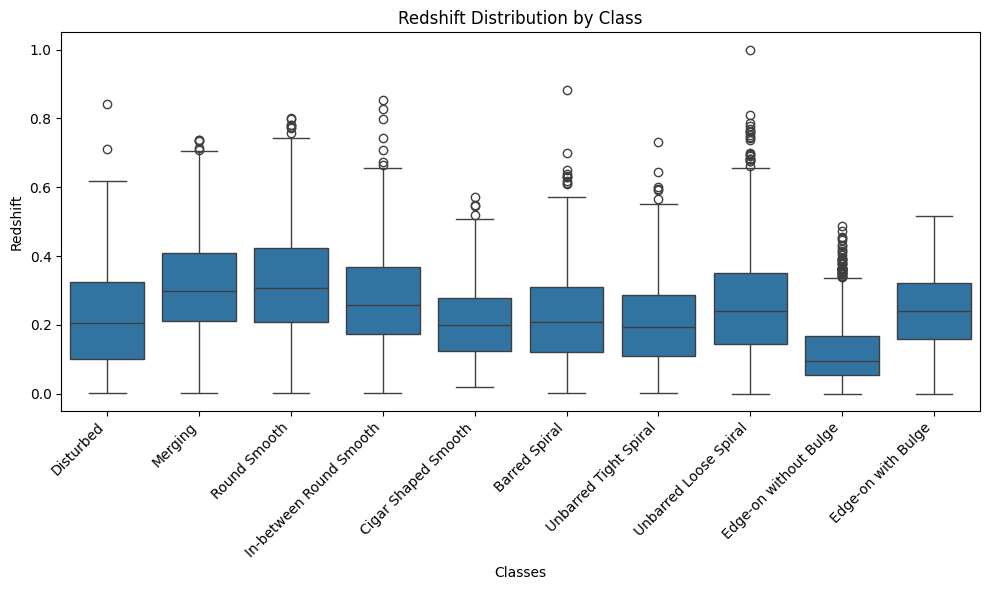

In [ ]:
# 4.4: Redshift by Class( after normalization))
plt.figure(figsize=(10, 6))
# Map the integer labels to class names for the x-axis using the cleaned labels
x_labels = [class_names[label] for label in labels_clean]
# Use the cleaned redshift_norm
sns.boxplot(x=x_labels, y=redshift_norm.flatten())
plt.xlabel('Classes')
plt.ylabel('Redshift')
plt.title('Redshift Distribution by Class')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
#plt.savefig(f'{data_path}/redshift_by_class_decals.png')
#plt.close()
#print("EDA plot saved: redshift_by_class_decals.png")

plt.show()

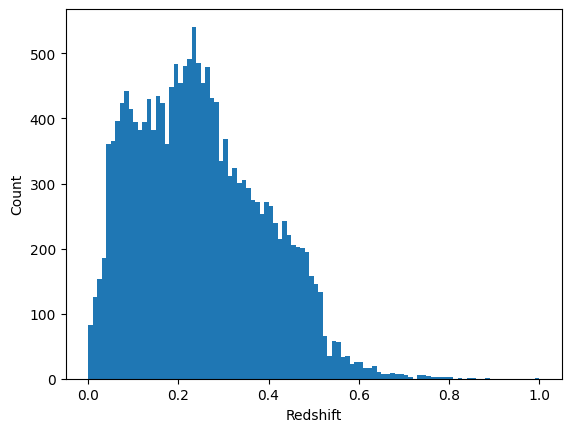

In [ ]:
# Distribution of redshift after cleaning

plt.hist(redshift_norm, bins=100)
plt.xlabel("Redshift")
plt.ylabel("Count")
plt.show()


In [ ]:
# Step 3: Batch Resize Images/ Normalize Image
# a. Normalizing the images

batch_size = 500
num_samples = images_clean.shape[0]
resized_images = np.zeros((num_samples, 64, 64, 3), dtype=np.float32)

print("Resizing images in batches")
for i in range(0, num_samples, batch_size):
    end_idx = min(i + batch_size, num_samples)
    batch = images_clean[i:end_idx].astype('float32')  # Normalize in batch
    resized_batch = tf.image.resize(batch, [64, 64], method='bilinear').numpy()/255
    resized_images[i:end_idx] = resized_batch
    print(f"Processed batch {i//batch_size + 1}/{(num_samples-1)//batch_size + 1}")



images_resized= resized_images
print(f"After resizing, Images shape: {images_resized.shape}, Labels shape: {labels.shape}")
print(f"Normalized images clean min: {images_resized.min():.4f}, max: {images_resized.max():.4f}")


Resizing images in batches...
Processed batch 1/36
Processed batch 2/36
Processed batch 3/36
Processed batch 4/36
Processed batch 5/36
Processed batch 6/36
Processed batch 7/36
Processed batch 8/36
Processed batch 9/36
Processed batch 10/36
Processed batch 11/36
Processed batch 12/36
Processed batch 13/36
Processed batch 14/36
Processed batch 15/36
Processed batch 16/36
Processed batch 17/36
Processed batch 18/36
Processed batch 19/36
Processed batch 20/36
Processed batch 21/36
Processed batch 22/36
Processed batch 23/36
Processed batch 24/36
Processed batch 25/36
Processed batch 26/36
Processed batch 27/36
Processed batch 28/36
Processed batch 29/36
Processed batch 30/36
Processed batch 31/36
Processed batch 32/36
Processed batch 33/36
Processed batch 34/36
Processed batch 35/36
Processed batch 36/36
After resizing, Images shape: (17556, 64, 64, 3), Labels shape: (17736,)
Normalized images clean min: 0.0000, max: 1.0000


In [ ]:
# b. Making 4channel input(64,64,4 input)
# Step 1: Reshape redshift to (B, 1, 1, 1)
z_scalar = redshift_norm[:, np.newaxis, np.newaxis, np.newaxis]  # (17641, 1, 1, 1)

# Step 2: Tile to (B, 64, 64, 1)
redshift_map = np.tile(z_scalar, (1, 64, 64, 1))  # (17641, 64, 64, 1)

# Step 3: Concatenate with images
images_4ch = np.concatenate([images_resized, redshift_map], axis=-1)  # (17641, 64, 64, 4)

print(f"Final 4-channel shape: {images_4ch.shape}")  #  (17641, 64, 64, 4)

Final 4-channel shape: (17556, 64, 64, 4)


In [ ]:
# # Check original pixel range after normalization
# print(images_4ch.min(), images_4ch.max(), images_4ch.dtype)
# print(f"Normalized images mean: {images_4ch.mean():.4f}, std: {images_4ch.std():.4f}")

0.0 1.0 float64


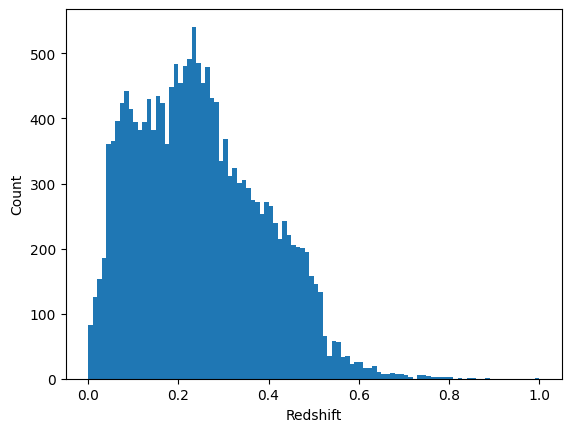

In [ ]:
# EDA:Distribution of redshift after normalization
plt.hist(redshift_norm, bins=100)
plt.xlabel("Redshift")
plt.ylabel("Count")
plt.show()

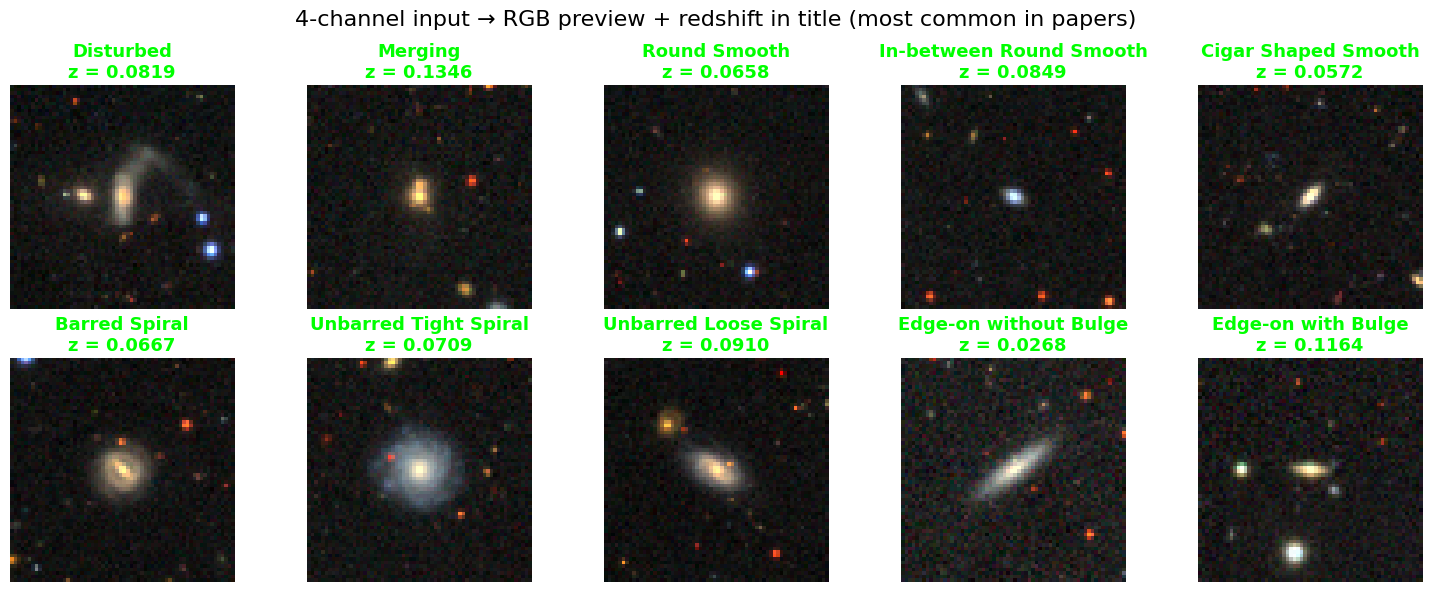

In [ ]:
# EDA: Sample Images after normalization(redshift)
plt.figure(figsize=(15,6))
for i in range(10):
    idx = np.where(labels_clean == i)[0][0]
    img4 = images_4ch[idx]                     # (64,64,4)
    rgb  = img4[..., :3]                       # take only RGB

    # Proper astronomical stretch
    lo, hi = np.percentile(rgb, [0.5, 99.9])
    rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

    plt.subplot(2,5,i+1)
    plt.imshow(rgb)
    z = redshift_clean[idx]
    plt.title(f"{class_names[i]}\nz = {z:.4f}", fontsize=13, color='lime', weight='bold')
    plt.axis('off')

plt.suptitle("4-channel input → RGB preview + redshift in title (most common in papers)",
             fontsize=16)
plt.tight_layout()
plt.show()

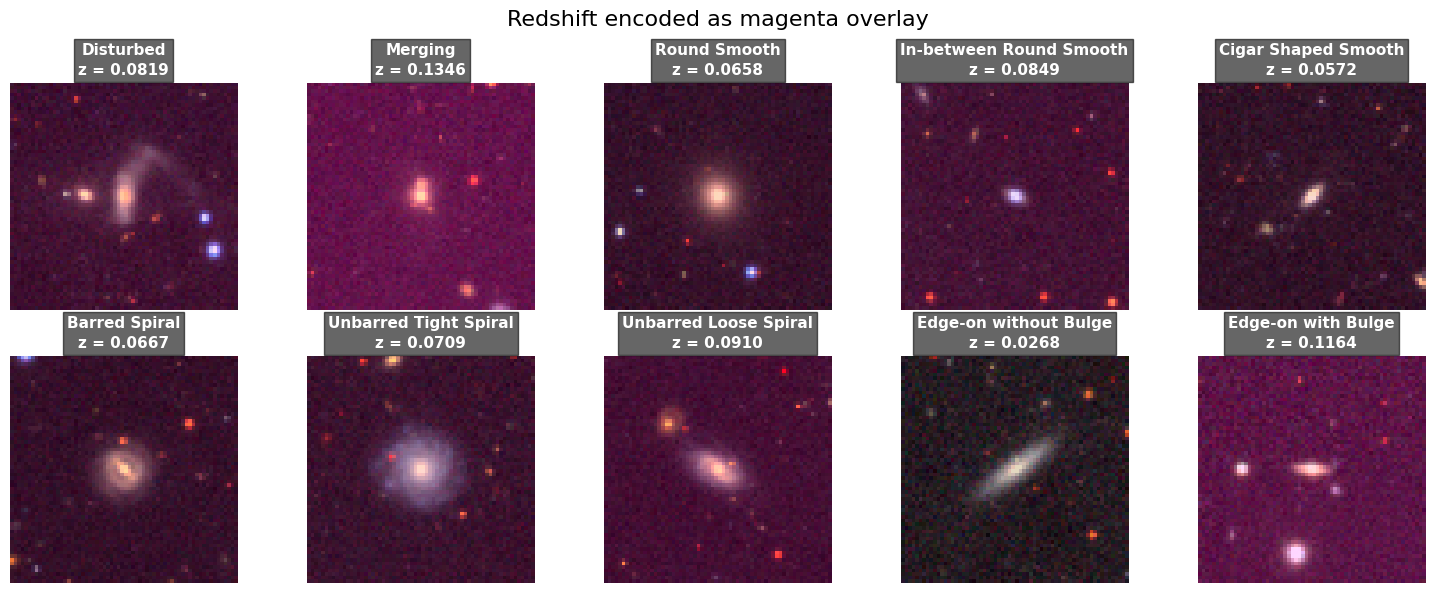

In [ ]:
# plt.figure(figsize=(15,6))
# for i in range(10):
#     idx = np.where(labels_clean == i)[0][0]
#     img4 = images_4ch[idx]
#     rgb  = img4[..., :3].copy()
#     z    = img4[0,0,3]                         # redshift value (same everywhere)

#     # Stretch RGB
#     lo, hi = np.percentile(rgb, [0.5, 99.9])
#     rgb = np.clip((rgb - lo) / (hi - lo + 1e-8), 0, 1)

#     # Redshift → magenta overlay (stronger = higher z)
#     overlay = np.zeros_like(rgb)
#     overlay[..., 0] = z          # red
#     overlay[..., 2] = z * 0.7    # blue → magenta

#     final = rgb * 0.85 + overlay * 0.7

#     plt.subplot(2,5,i+1)
#     plt.imshow(np.clip(final,0,1))

#     plt.title(f"{class_names[i]}\nz = {redshift_clean[idx]:.4f}",
#               color='white', fontsize=11, weight='bold', linespacing=1.4,
#               bbox=dict(facecolor='black', alpha=0.6, pad=3))

#     plt.axis('off')

# plt.suptitle("Redshift encoded as magenta overlay", fontsize=16)
# plt.tight_layout()
# plt.show()

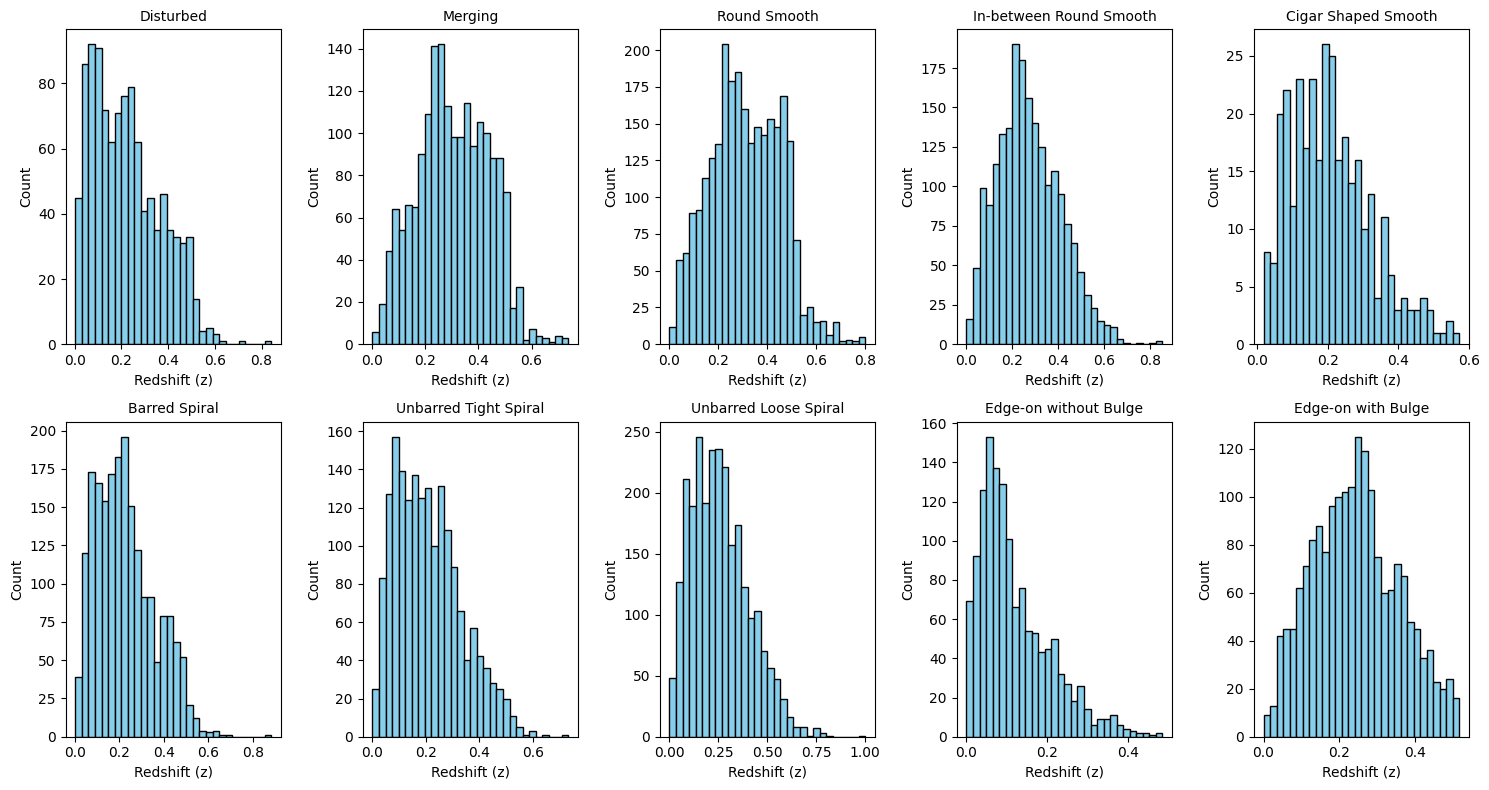

In [ ]:
plt.figure(figsize=(15, 8))
for i, cname in enumerate(class_names):
    plt.subplot(2, 5, i + 1)
    class_z = redshift_norm[labels_clean == i]
    plt.hist(class_z, bins=30, color='skyblue', edgecolor='black')
    plt.title(cname, fontsize=10)
    plt.xlabel("Redshift (z)")
    plt.ylabel("Count")
plt.tight_layout()
plt.show()

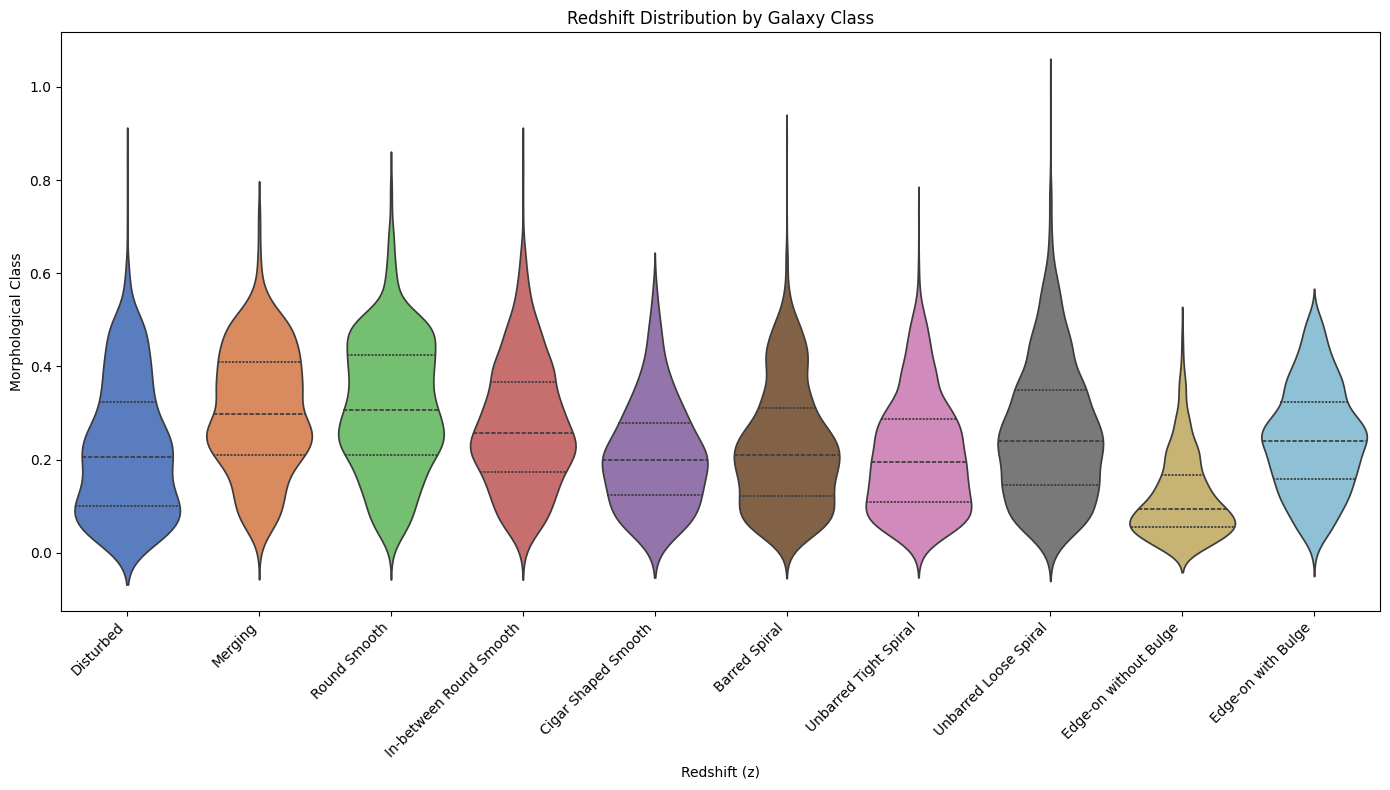

In [ ]:
# Violine Plot for Normalized redshift data
plt.figure(figsize=(14,8))
sns.violinplot(x=x_labels, y=redshift_norm, inner="quart", hue=x_labels, density_norm="width", palette="muted", legend=False)

plt.title("Redshift Distribution by Galaxy Class")
plt.xlabel("Redshift (z)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Morphological Class")
plt.tight_layout()
plt.show()

In [ ]:
# Save preprocessed data
np.save(f'{data_path}/images_aug.npy',images_resized )
np.save(f'{data_path}/labels_aug.npy', labels_clean)
np.save(f'{data_path}/redshift_aug.npy', redshift_norm)

print(f"Saved preprocessed data to {data_path}: images_aug.npy, labels_aug.npy, redshift_aug.npy")

Saved preprocessed data to /content/drive/MyDrive/dataset: images_aug.npy, labels_aug.npy, redshift_aug.npy


In [ ]:
#Load preprocessed data( after EDA )
data_path = '/content/drive/MyDrive/dataset'
images_3ch = np.load(f'{data_path}/images_aug.npy')
labels_clean= np.load(f'{data_path}/labels_aug.npy')



class_names = ['Disturbed', 'Merging', 'Round Smooth', 'In-between Round Smooth',
               'Cigar Shaped Smooth', 'Barred Spiral', 'Unbarred Tight Spiral',
               'Unbarred Loose Spiral', 'Edge-on without Bulge', 'Edge-on with Bulge']
num_classes = len(class_names)

print(f"Loaded preprocessed data from {data_path}: images.npy, labels.npy, redshit.npy")

Loaded preprocessed data from /content/drive/MyDrive/dataset: images.npy, labels.npy, redshit.npy


In [ ]:
print(type(images_4ch))
print(type(labels_clean))


print(f"Images shape: {images_4ch.shape}, Labels clean shape: {labels_clean.shape}")
print(f"Normalized images min: {images_4ch.min():.4f}, max: {images_4ch.max():.4f}")
print(f"Normalized images mean: {images_4ch.mean():.4f}, std: {images_4ch.std():.4f}")

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Images shape: (17556, 64, 64, 4), Labels clean shape: (17556,)
Normalized images min: 0.0000, max: 1.0000
Normalized images mean: 0.1842, std: 0.1257


In [ ]:
#   # STEP 1: Split into train + (val+test) (70% train, 30% temp)
# train_idx, tmp_idx = train_test_split(
#     np.arange(len(images_4ch)),
#     test_size=0.3,
#     stratify=labels_clean,
#     random_state=42
# )

# # STEP 2: Split temp into val + test (50/50)
# val_idx, test_idx = train_test_split(
#     tmp_idx,
#     test_size=0.5,
#     stratify=labels_clean[tmp_idx],
#     random_state=42
# )

# # STEP 3: Verify splits
# print(f"Train size: {len(train_idx)} ({100*len(train_idx)/len(images_4ch):.1f}%)")
# print(f"Val size:   {len(val_idx)} ({100*len(val_idx)/len(images_4ch):.1f}%)")
# print(f"Test size:  {len(test_idx)} ({100*len(test_idx)/len(images_4ch):.1f}%)")
# print(f"Total: {len(train_idx) + len(val_idx) + len(test_idx)} ({len(images_4ch)})")


Train size: 12289 (70.0%)
Val size:   2633 (15.0%)
Test size:  2634 (15.0%)
Total: 17556 (17556)


In [ ]:
# STEP 2: Count classes in each split
train_images = images_4ch[train_idx]
train_labels = labels_clean[train_idx]

val_images = images_4ch[val_idx]
val_labels = labels_clean[val_idx]

test_images = images_4ch[test_idx]
test_labels = labels_clean[test_idx]


# STEP 2: Count class frequencies
class_counts = Counter(train_labels)
print("Class counts in training:", class_counts)

# STEP 3: Target count = largest class
target_count = max(class_counts.values())
print(f"\nTarget count (largest class): {target_count}")


# STEP 4: Print class counts clearly
print("\nTraining set class counts:")
for c in sorted(class_counts.keys()):
    print(f"Class {c}: {class_counts[c]} images")

# STEP 5: Total train images
print("\nTotal training images:", len(train_labels))


Class counts in training: Counter({np.uint8(2): 1841, np.uint8(7): 1825, np.uint8(5): 1418, np.uint8(3): 1413, np.uint8(9): 1304, np.uint8(1): 1287, np.uint8(6): 1268, np.uint8(8): 956, np.uint8(0): 745, np.uint8(4): 232})

Target count (largest class): 1841

Training set class counts:
Class 0: 745 images
Class 1: 1287 images
Class 2: 1841 images
Class 3: 1413 images
Class 4: 232 images
Class 5: 1418 images
Class 6: 1268 images
Class 7: 1825 images
Class 8: 956 images
Class 9: 1304 images

Total training images: 12289


In [ ]:
# 2. Augmentation function (4-channel)
#a. Preprocessing layers for rotation and translation
random_rotation = tf.keras.layers.RandomRotation(
    factor=0.10,
    fill_mode="reflect"
)

random_translation = tf.keras.layers.RandomTranslation(
    height_factor=0.05,
    width_factor=0.05,
    fill_mode="reflect"
)


def augment_fn(image_4ch, label):
    img = tf.cast(image_4ch, tf.float32)

    #1.Separate RGB and redshift(split RGB and Redshift)
    rgb = img[:, :, :3] #(64,64,3)
    z_map = img[:, :, 3:] #(64,64,1)
    # 2.Geometric: flip (applied to only on grb channels)
    rgb = tf.image.random_flip_left_right(rgb)
    rgb = tf.image.random_flip_up_down(rgb)

    # Rotation
    rgb = random_rotation(rgb, training=True)

    # Translation (±5%)
    rgb = random_translation(rgb, training=True)

    #3.Photometric: ONLY on RGB
    rgb = tf.image.random_brightness(rgb, max_delta=0.1)
    rgb = tf.image.random_contrast(rgb, lower=0.9, upper=1.1)
    rgb = tf.image.random_saturation(rgb, lower=0.9, upper=1.1)

    # Apply Gaussian background noise
    def add_background_noise(rgb):
        noise = tf.random.normal(tf.shape(rgb), mean=0.0, stddev=0.005)
        return tf.clip_by_value(rgb + noise, 0.0, 1.0)

    rgb = tf.cond(
        tf.random.uniform([]) < 0.30,
        lambda: add_background_noise(rgb),
        lambda: rgb
    )
    #  Added smooth gradient background
    def add_background_gradient(rgb):
        x = tf.linspace(0.0, 1.0, 64)
        y = tf.linspace(0.0, 1.0, 64)
        X, Y = tf.meshgrid(x, y)

        strength = tf.random.uniform([], 0.01, 0.02)
        angle = tf.random.uniform([], 0.0, 6.28318)  # 0–2π

        grad = strength * (X * tf.cos(angle) + Y * tf.sin(angle))
        grad = grad[..., tf.newaxis]   # (64,64,1)
        return tf.clip_by_value(rgb + grad, 0.0, 1.0)

    rgb = tf.cond(
        tf.random.uniform([]) < 0.25,   # 25% chance
        lambda: add_background_gradient(rgb),
        lambda: rgb
    )
    # FINAL SAFE CLIP (important)
    rgb = tf.clip_by_value(rgb, 0.0, 1.0)

    # REDSHIFT AUGMENTATION
    def add_redshift_noise(z_map):
        noise = tf.random.normal(tf.shape(z_map), mean=0.0, stddev=0.002) # Corrected variable from 'z' to 'z_map'
        return tf.clip_by_value(z_map + noise, 0.0, 1.0)

    # 50% chance of tiny noise
    z_map= tf.cond(
        tf.random.uniform([]) < 0.50,
        lambda: add_redshift_noise(z_map),
        lambda: z_map
    )


    # Re-stack
    img = tf.concat([rgb, z_map], axis=-1)
    return img, label

In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
class_datasets = []
target_count = 1848  # define this earlier in your code

print("Balancing classes to target_count =", target_count)
print("-" * 50)

for cls in sorted(class_counts.keys()):
    # Find indices for this class
    cls_idx = np.where(train_labels == cls)[0]
    n_samples = len(cls_idx)

    # Extract images and labels
    cls_imgs = train_images[cls_idx]
    cls_labs = train_labels[cls_idx]

    print(f"Class {cls:2d}: {n_samples:4d} → {target_count}")

    # Create dataset from tensors
    cls_ds = tf.data.Dataset.from_tensor_slices((cls_imgs, cls_labs))

    # Shuffle original data
    cls_ds = cls_ds.shuffle(buffer_size=n_samples, seed=42, reshuffle_each_iteration=True)

    # Apply augmentation to original samples
    cls_ds = cls_ds.map(augment_fn, num_parallel_calls=AUTOTUNE)

    # Now: oversample by repeating + take exactly target_count
    if n_samples < target_count:
        # Repeat the dataset enough times to exceed target_count
        repeats_needed = (target_count // n_samples) + 1
        cls_ds = cls_ds.repeat(repeats_needed)

    # Take exactly target_count samples (this handles both over and under sampling)
    cls_ds = cls_ds.take(target_count)

    # Optional: shuffle again after take/repeat for better mixing
    cls_ds = cls_ds.shuffle(buffer_size=target_count, reshuffle_each_iteration=True)

    class_datasets.append(cls_ds)

print("\nClass datasets created:", len(class_datasets))
print("Each class now has exactly", target_count, "samples (after augmentation & balancing)")

Balancing classes to target_count = 1848
--------------------------------------------------
Class  0:  745 → 1848
Class  1: 1287 → 1848
Class  2: 1841 → 1848
Class  3: 1413 → 1848
Class  4:  232 → 1848
Class  5: 1418 → 1848
Class  6: 1268 → 1848
Class  7: 1825 → 1848
Class  8:  956 → 1848
Class  9: 1304 → 1848

Class datasets created: 10
Each class now has exactly 1848 samples (after augmentation & balancing)


In [ ]:
batch_size = 64
balanced_ds = tf.data.Dataset.concatenate(class_datasets[0], class_datasets[1])
for ds in class_datasets[2:]:
    balanced_ds = balanced_ds.concatenate(ds)

train_ds = balanced_ds.shuffle(20000).batch(batch_size).prefetch(AUTOTUNE)
#Validation/Test
val_ds = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
val_ds = val_ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

test_ds = tf.data.Dataset.from_tensor_slices((test_images, test_labels))
test_ds = test_ds.batch(batch_size)

In [ ]:
counts_balanced = {i: 0 for i in range(len(class_counts))}

for img, lab in train_ds.unbatch():
    counts_balanced[int(lab.numpy())] += 1

counts_balanced


{0: 1848,
 1: 1848,
 2: 1848,
 3: 1848,
 4: 1848,
 5: 1848,
 6: 1848,
 7: 1848,
 8: 1848,
 9: 1848}

Collected classes: dict_keys([1, 0, 7, 9, 6, 3, 2, 5, 8, 4])


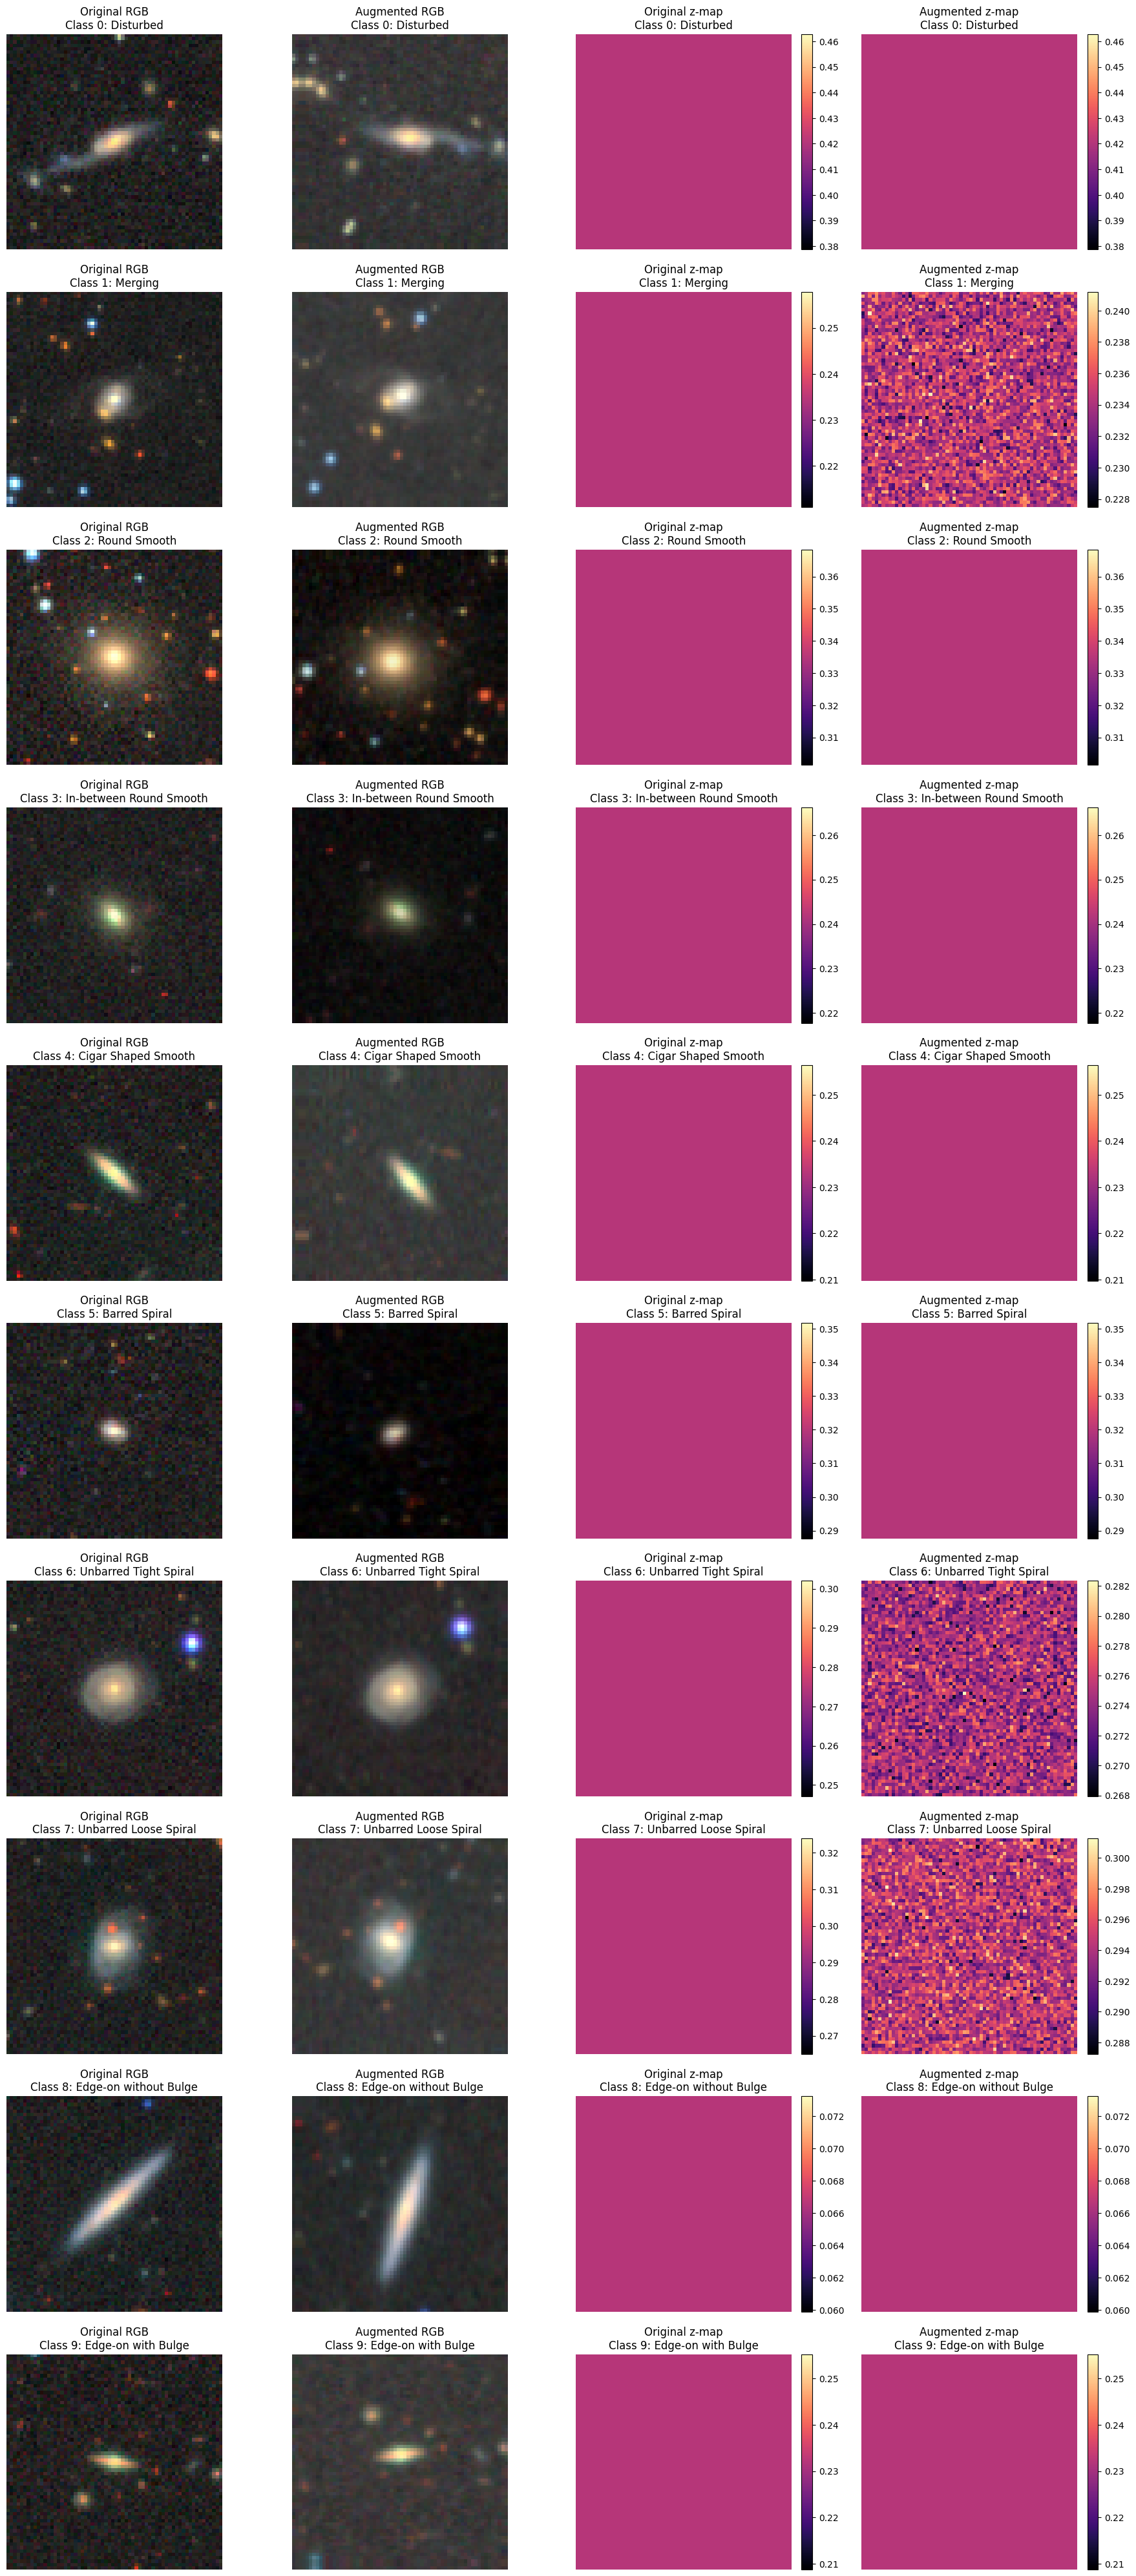

In [ ]:
# Test1: QUALITATIVE CHECK of augmentation
'''ORIGINAL vs AUGMENTED (RGB + Redshift) — Per Class (10 classes)
'''
# Step a: Pick 1 representative image per class
class_examples = {}  # {class_id: image}

for img, lab in zip(train_images, train_labels):
    lab = int(lab)
    if lab not in class_examples:
        class_examples[lab] = img
    if len(class_examples) == num_classes:
        break

print("Collected classes:", class_examples.keys())


# Step b: Augment once per class
aug_examples = {}

for lab, img in class_examples.items():
    aug_img, _ = augment_fn(tf.constant(img), tf.constant(lab))
    aug_examples[lab] = aug_img.numpy()


# Step c: Plot (10 rows × 4 columns)
plt.figure(figsize=(18, 40))

for idx, lab in enumerate(sorted(class_examples.keys())):

    orig = class_examples[lab]
    aug  = aug_examples[lab]

    orig_rgb = orig[:, :, :3]
    orig_z   = orig[:, :, 3]

    aug_rgb = aug[:, :, :3]
    aug_z   = aug[:, :, 3]

    class_name = class_names[lab]

    # Column 1 — Original RGB
    plt.subplot(10, 4, 4*idx + 1)
    plt.imshow(orig_rgb)
    plt.title(f"Original RGB\nClass {lab}: {class_name}")
    plt.axis("off")

    # Column 2 — Augmented RGB
    plt.subplot(10, 4, 4*idx + 2)
    plt.imshow(aug_rgb)
    plt.title(f"Augmented RGB\nClass {lab}: {class_name}")
    plt.axis("off")

    # Column 3 — Original Redshift Map
    plt.subplot(10, 4, 4*idx + 3)
    plt.imshow(orig_z, cmap="magma")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"Original z-map\nClass {lab}: {class_name}")
    plt.axis("off")

    # Column 4 — Augmented Redshift Map
    plt.subplot(10, 4, 4*idx + 4)
    plt.imshow(aug_z, cmap="magma")
    plt.colorbar(fraction=0.046, pad=0.04)
    plt.title(f"Augmented z-map\nClass {lab}: {class_name}")
    plt.axis("off")

plt.tight_layout()
plt.show()


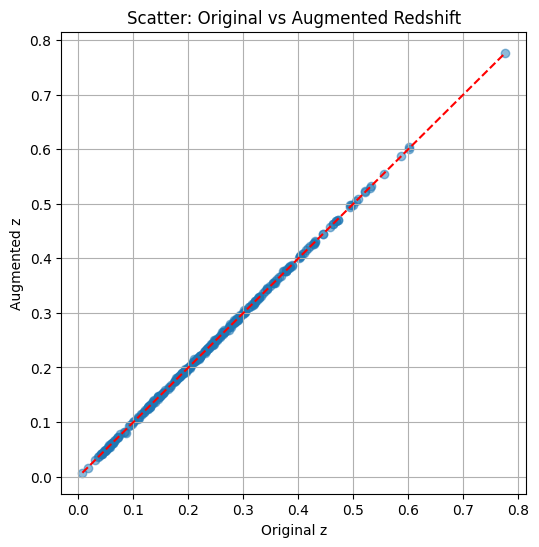

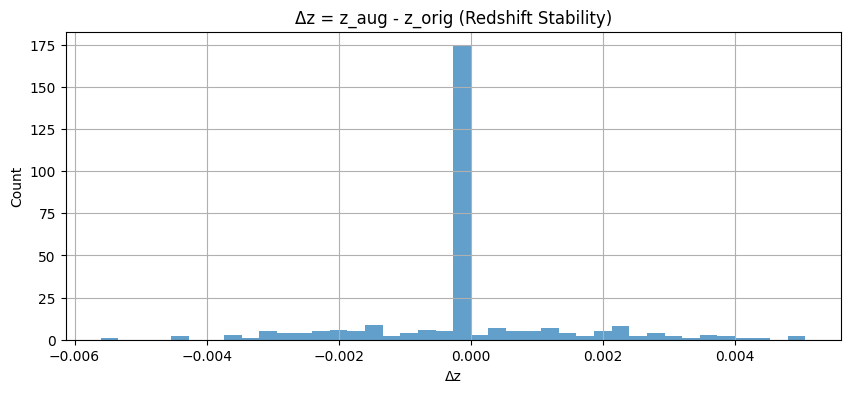

In [ ]:
# TEST 2: Δz STABILITY (Augmented vs Original)
'''Scatter Plot + Δz Histogram
'''
# Step 1: Collect original & augmented z for SAME images
n = 300   # number of samples to compare
orig_sample = train_images[:n]

orig_values = np.array([img[0,0,3] for img in orig_sample])
aug_values  = []

for img in orig_sample:
    aug_img, _ = augment_fn(tf.constant(img), tf.constant(0))
    aug_values.append(float(aug_img.numpy()[0,0,3]))

aug_values = np.array(aug_values)


# Step 2: Compute Δz
dz = aug_values - orig_values


# Step 3: SCATTER: z_orig vs z_aug
plt.figure(figsize=(6,6))
plt.scatter(orig_values, aug_values, alpha=0.5)
plt.plot([orig_values.min(), orig_values.max()],
         [orig_values.min(), orig_values.max()], 'r--')
plt.xlabel("Original z")
plt.ylabel("Augmented z")
plt.title("Scatter: Original vs Augmented Redshift")
plt.grid(True)
plt.show()


#Step 4: Δz HISTOGRAM
plt.figure(figsize=(10,4))
plt.hist(dz, bins=40, alpha=0.7)
plt.title("Δz = z_aug - z_orig (Redshift Stability)")
plt.xlabel("Δz")
plt.ylabel("Count")
plt.grid(True)
plt.show()


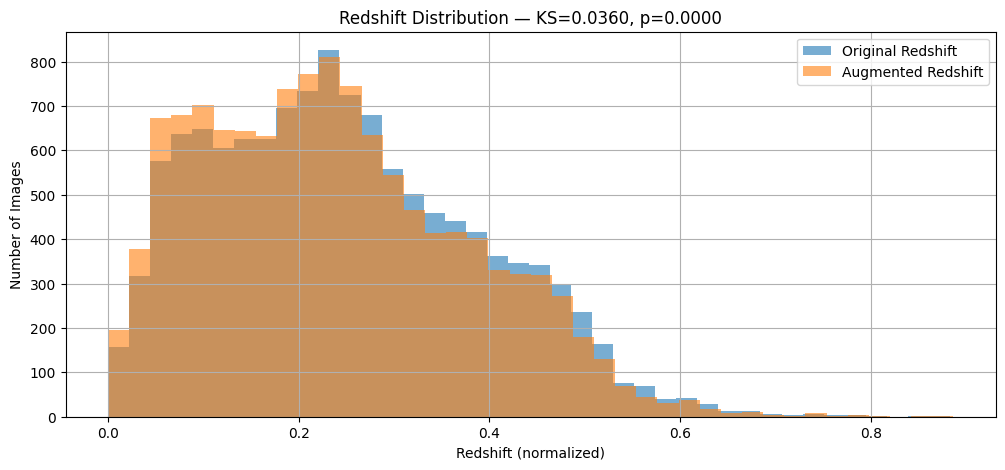

In [ ]:
# Test3: Redshift Distribution (Before vs After) + KS Test
# 1 — ORIGINAL redshift (each image has 1 redshift value)
from scipy.stats import ks_2samp
orig_z_values = np.array([img[0,0,3] for img in train_images])


# 2 — AUGMENTED redshift
aug_z_values = []

for img, _ in train_ds.unbatch().take(len(orig_z_values)):
    z_map = img.numpy()[:,:,3]
    aug_z_values.append(z_map[0,0])

aug_z_values = np.array(aug_z_values)

# Step 3: KS Test
ks_stat, ks_p = ks_2samp(orig_z_values, aug_z_values)
# 4: hist plot with KDe
plt.figure(figsize=(12,5))
plt.hist(orig_z_values, bins=40, alpha=0.6, label='Original Redshift')
plt.hist(aug_z_values, bins=40, alpha=0.6, label='Augmented Redshift')
plt.xlabel("Redshift (normalized)")
plt.ylabel("Number of Images")
plt.title(f"Redshift Distribution — KS={ks_stat:.4f}, p={ks_p:.4f}")
# plt.title("Original vs Augmented Redshift Distribution")
plt.legend()
plt.grid(True)
plt.show()

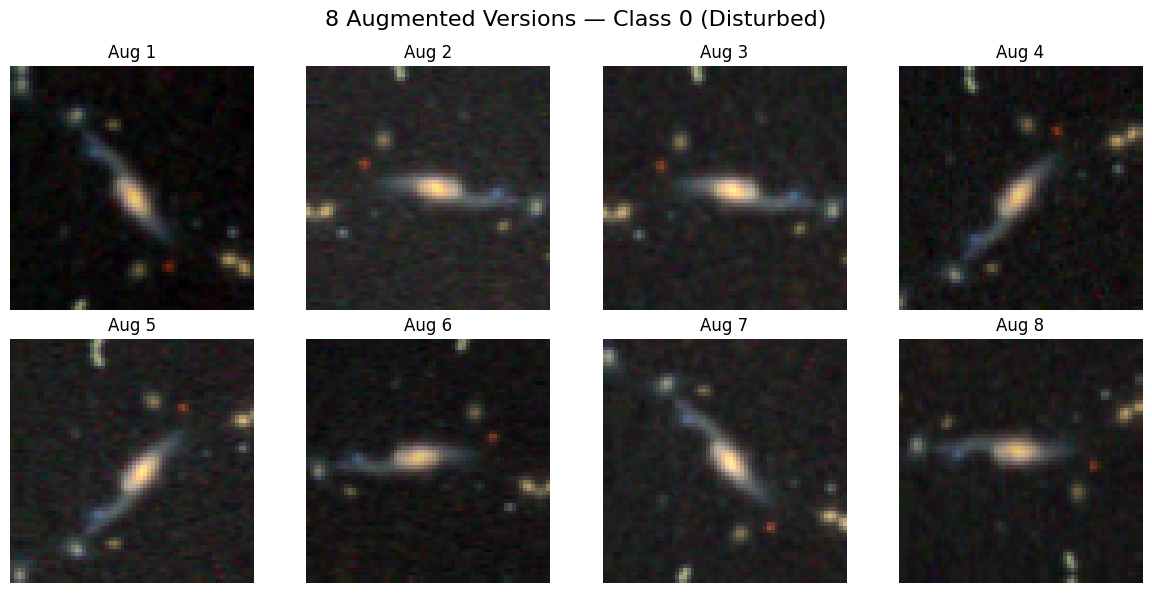

In [ ]:
# test4: 8 Augmentations of One Image
sample_lab = 0
sample_img = class_examples[sample_lab]

plt.figure(figsize=(12, 6))
for i in range(8):
    aug_img, _ = augment_fn(tf.constant(sample_img), tf.constant(sample_lab))
    aug_rgb = np.clip(aug_img.numpy()[:,:,:3], 0, 1)

    plt.subplot(2, 4, i+1)
    plt.imshow(aug_rgb)
    plt.title(f"Aug {i+1}")
    plt.axis("off")

plt.suptitle(f"8 Augmented Versions — Class {sample_lab} ({class_names[sample_lab]})", fontsize=16)
plt.tight_layout()
plt.show()


Random sample index: 10744, class = 8

 PIXEL STATISTICS (RGB only)
Original: mean = 0.1647
Augmented: mean = 0.2316
Difference (aug - orig) = 0.0669

Augmented RGB min  : 0.0977
Augmented RGB max  : 1.0000
Augmented RGB std  : 0.1029


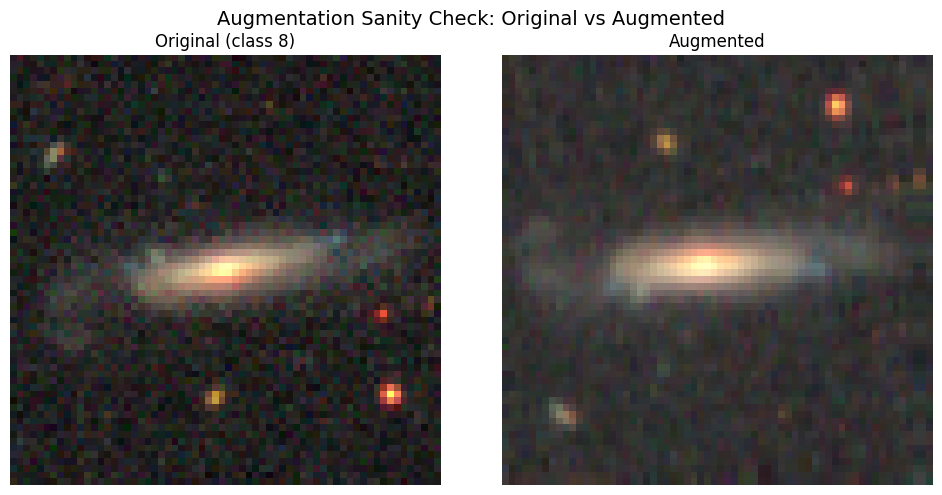

In [ ]:
# Step 4: Augmentation Sanity Check: Original vs Augmented

# 1) Pick a random training image
idx = np.random.randint(len(train_images))
orig_img = train_images[idx]
orig_label = train_labels[idx]

print(f"Random sample index: {idx}, class = {orig_label}")

# 2) Apply augmentation ONCE
aug_img, _ = augment_fn(tf.constant(orig_img), tf.constant(orig_label))
aug_img = aug_img.numpy()

# 3) Compute stats (RGB only)
orig_rgb = orig_img[..., :3].astype("float32")
aug_rgb  = aug_img[..., :3].astype("float32")

orig_mean = orig_rgb.mean()
aug_mean  = aug_rgb.mean()
diff_mean = aug_mean - orig_mean

print("\n PIXEL STATISTICS (RGB only)")
print(f"Original: mean = {orig_mean:.4f}")
print(f"Augmented: mean = {aug_mean:.4f}")
print(f"Difference (aug - orig) = {diff_mean:.4f}")

print(f"\nAugmented RGB min  : {aug_rgb.min():.4f}")
print(f"Augmented RGB max  : {aug_rgb.max():.4f}")
print(f"Augmented RGB std  : {aug_rgb.std():.4f}")

# 4) Plot original vs augmented
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(np.clip(orig_rgb, 0, 1))
plt.title(f"Original (class {orig_label})")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(np.clip(aug_rgb, 0, 1))
plt.title("Augmented")
plt.axis("off")

plt.suptitle("Augmentation Sanity Check: Original vs Augmented", fontsize=14)
plt.tight_layout()
plt.show()


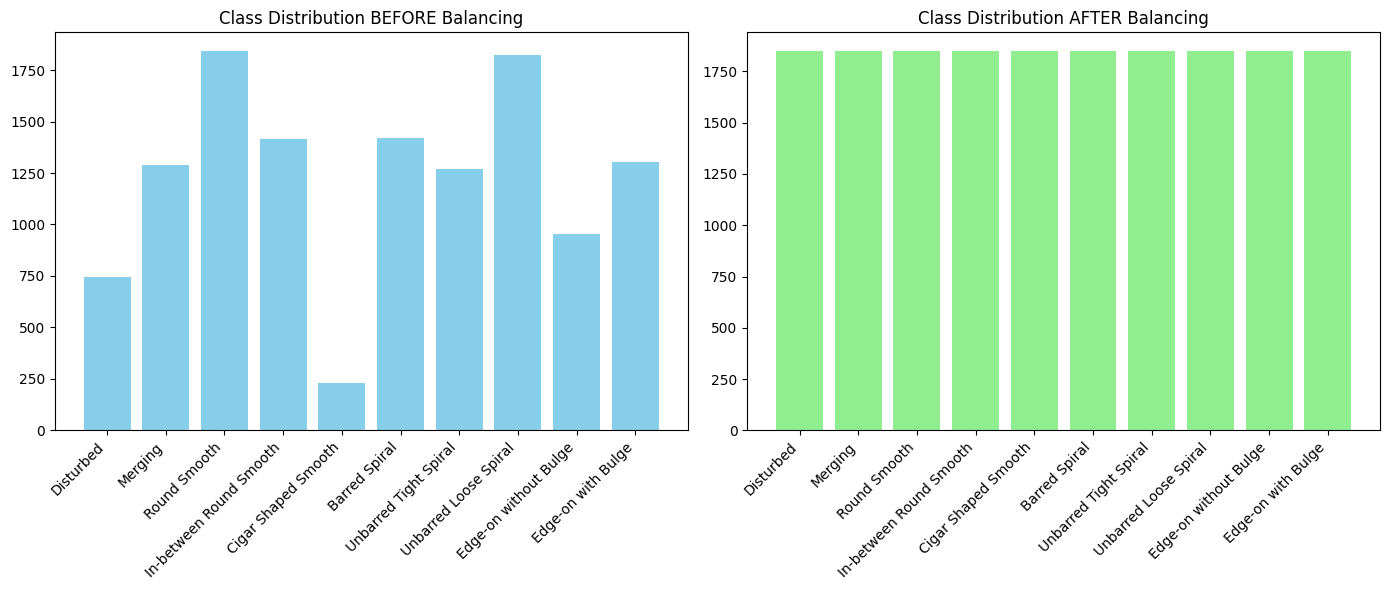


Counts after balancing:
Class 0: 1848
Class 1: 1848
Class 2: 1848
Class 3: 1848
Class 4: 1848
Class 5: 1848
Class 6: 1848
Class 7: 1848
Class 8: 1848
Class 9: 1848


In [ ]:
# Step5:Distribution of train data before and after augmentation

# BEFORE augmentation
counts_before = Counter(train_labels)

# Number of total samples in balanced dataset
num_samples = sum([len(ds) for ds in class_datasets])  # correct sample count
num_batches = int(np.ceil(num_samples / batch_size))

# AFTER augmentation/balancing
all_labels = []
for _, lab_batch in train_ds.take(num_batches):
    all_labels.extend(lab_batch.numpy())

counts_after = Counter(all_labels)

# Plotting
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.bar(range(10), [counts_before[i] for i in range(10)], color='skyblue')
plt.title("Class Distribution BEFORE Balancing")
plt.xticks(range(10), class_names, rotation=45, ha='right')

plt.subplot(1, 2, 2)
plt.bar(range(10), [counts_after[i] for i in range(10)], color='lightgreen')
plt.title("Class Distribution AFTER Balancing")
plt.xticks(range(10), class_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

print("\nCounts after balancing:")
for i in range(10):
    print(f"Class {i}: {counts_after[i]}")


In [ ]:
# # 3. Apply augmentation, batch, prefetch
# import math
# target_count = max(class_counts.values())
# num_classes = len(class_counts)

# STEPS_PER_EPOCH = math.ceil((target_count * num_classes) / BATCH_SIZE)

# print(STEPS_PER_EPOCH)


In [ ]:
# Model 1:galaxynet_cnn_mc
def build_galaxynet_cnn_mc(input_shape=(64,64,4), n_class=10, dropout_p=0.3):

    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(0.2)(x, training=True)

    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 2
    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 3
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 4
    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(256, 3, padding='same',)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_p)(x, training=True)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_p)(x, training=True)

    logits = layers.Dense(n_class)(x)

    return models.Model(inputs, logits, name="GalaxyNet_CNN_MC")


In [ ]:
# Build Model A
model_a = build_galaxynet_cnn_mc(input_shape=(64,64,4), n_class=10)

optimizer = tf.keras.optimizers.Adam(0.001)
# Compile
model_a.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
#model_a.summary()

In [ ]:
# Callbacks
callbacks = [
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta = 0.001,
        mode ='min',
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        'models/cnn_mc_dropout_best.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )]

In [ ]:
# Training
history = model_a.fit(
    train_ds,
    validation_data=val_ds,
    epochs=120, # we can use more epoch next day
    #steps_per_epoch=STEPS_PER_EPOCH,
    callbacks=callbacks,
    verbose = 1
)

Epoch 1/120
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.1366 - loss: 2.2648
Epoch 1: val_accuracy improved from -inf to 0.15875, saving model to models/cnn_mc_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.1367 - loss: 2.2646 - val_accuracy: 0.1588 - val_loss: 2.4630 - learning_rate: 0.0010
Epoch 2/120
285/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1992 - loss: 2.1105
Epoch 2: val_accuracy improved from 0.15875 to 0.25978, saving model to models/cnn_mc_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step - accuracy: 0.1992 - loss: 2.1104 - val_accuracy: 0.2598 - val_loss: 1.9745 - learning_rate: 0.0010
Epoch 3/120
288/289 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2164 - loss: 2.0549
Epoch 3: val_accuracy improved from 0.25978 to 0.28523, saving model to models/cnn_mc_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.2164 - loss: 2.0548 - val_accuracy: 0.2852 - val_loss: 1.9101 - learning_rate: 0.001

In [ ]:
# Saved Model Later
model = tf.keras.models.load_model("models/cnn_mc_dropout_best.keras")


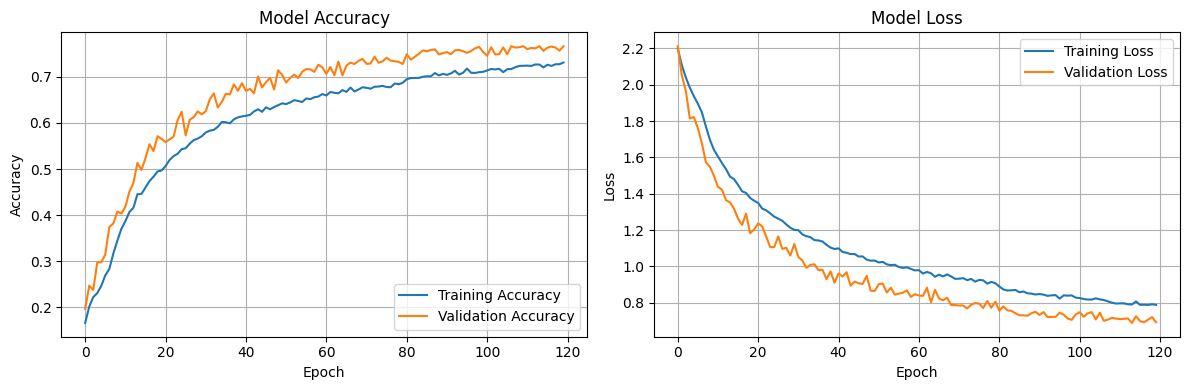

In [ ]:
def plot_training_history(history):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history)

In [ ]:
# Classical Evaluation (Non-Bayesian)
# Standard test evaluation
test_loss, test_acc = model_a.evaluate(test_ds, verbose=1)

print(f"Test Accuracy (Classical): {test_acc:.4f}")
print(f"Test Loss       (Classical): {test_loss:.4f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - accuracy: 0.7439 - loss: 0.7384
Test Accuracy (Classical): 0.7513
Test Loss       (Classical): 0.7045


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

def get_classical_predictions(model, test_ds):
    all_preds = []
    all_labels = []

    for imgs, labels in test_ds:
        logits = model(imgs, training=False)      # disable dropout
        probs  = tf.nn.softmax(logits, axis=-1)   # convert logits → probabilities

        all_preds.append(probs.numpy())
        all_labels.append(labels.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    y_pred = np.argmax(all_preds, axis=1)
    y_true = all_labels

    return y_true, y_pred


In [ ]:
y_true, y_pred = get_classical_predictions(model, test_ds)

accuracy  = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
f1        = f1_score(y_true, y_pred, average='macro')

print("Classical Model Evaluation (No MC Dropout)")
print("-------------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Classical Model Evaluation (No MC Dropout)
-------------------------------------------
Accuracy : 0.7521
Precision: 0.7132
Recall   : 0.7495
F1-score : 0.7195


In [ ]:
print("\nClassification Report (Macro averaged):")
print(classification_report(y_true, y_pred, target_names=class_names))



Classification Report (Macro averaged):
                         precision    recall  f1-score   support

              Disturbed       0.46      0.28      0.35       159
                Merging       0.81      0.73      0.77       275
           Round Smooth       0.83      0.91      0.87       395
In-between Round Smooth       0.82      0.93      0.87       303
    Cigar Shaped Smooth       0.64      0.64      0.64        50
          Barred Spiral       0.73      0.80      0.76       304
  Unbarred Tight Spiral       0.71      0.73      0.72       271
  Unbarred Loose Spiral       0.70      0.57      0.63       392
  Edge-on without Bulge       0.78      0.88      0.83       205
     Edge-on with Bulge       0.82      0.87      0.84       280

               accuracy                           0.76      2634
              macro avg       0.73      0.73      0.73      2634
           weighted avg       0.75      0.76      0.75      2634



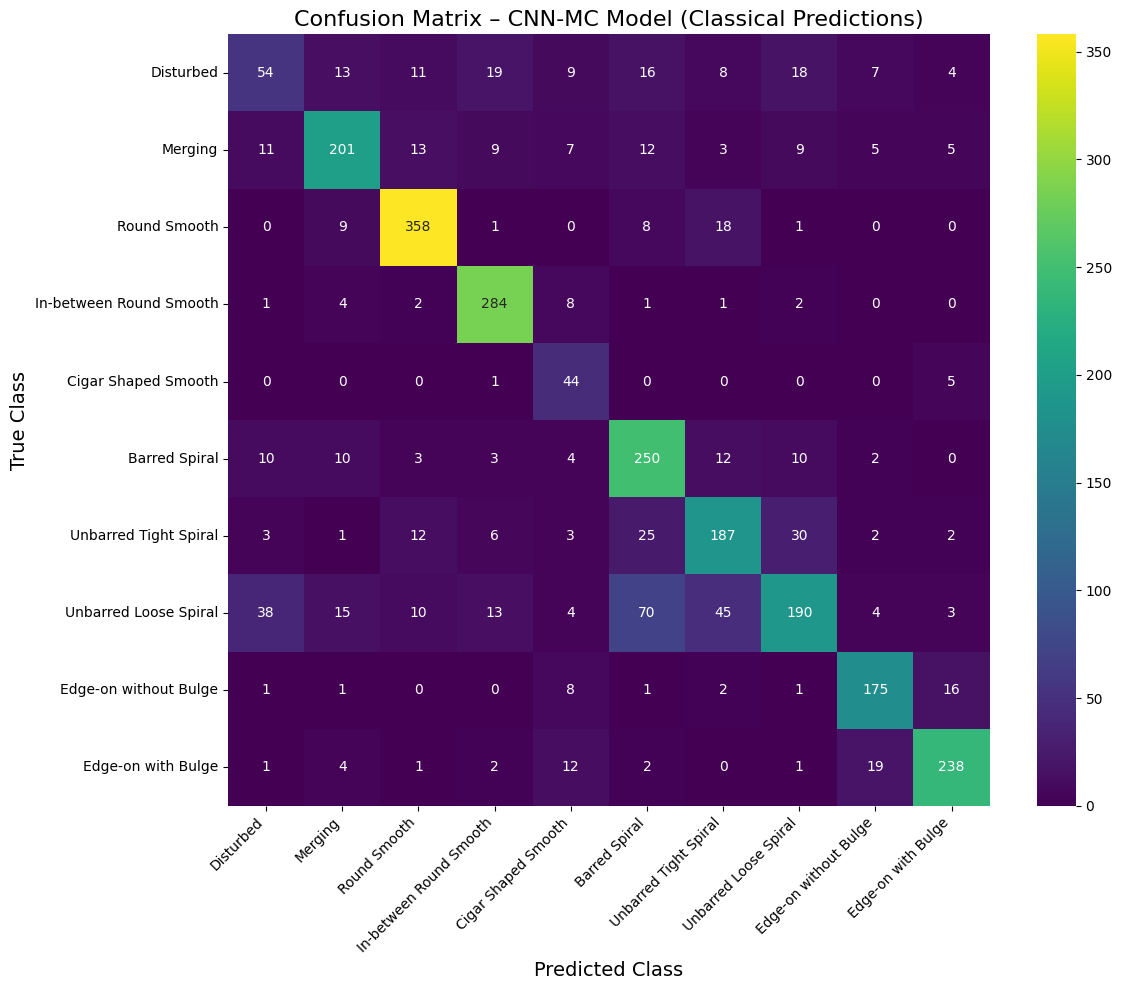

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN-MC Model (Classical Predictions)", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


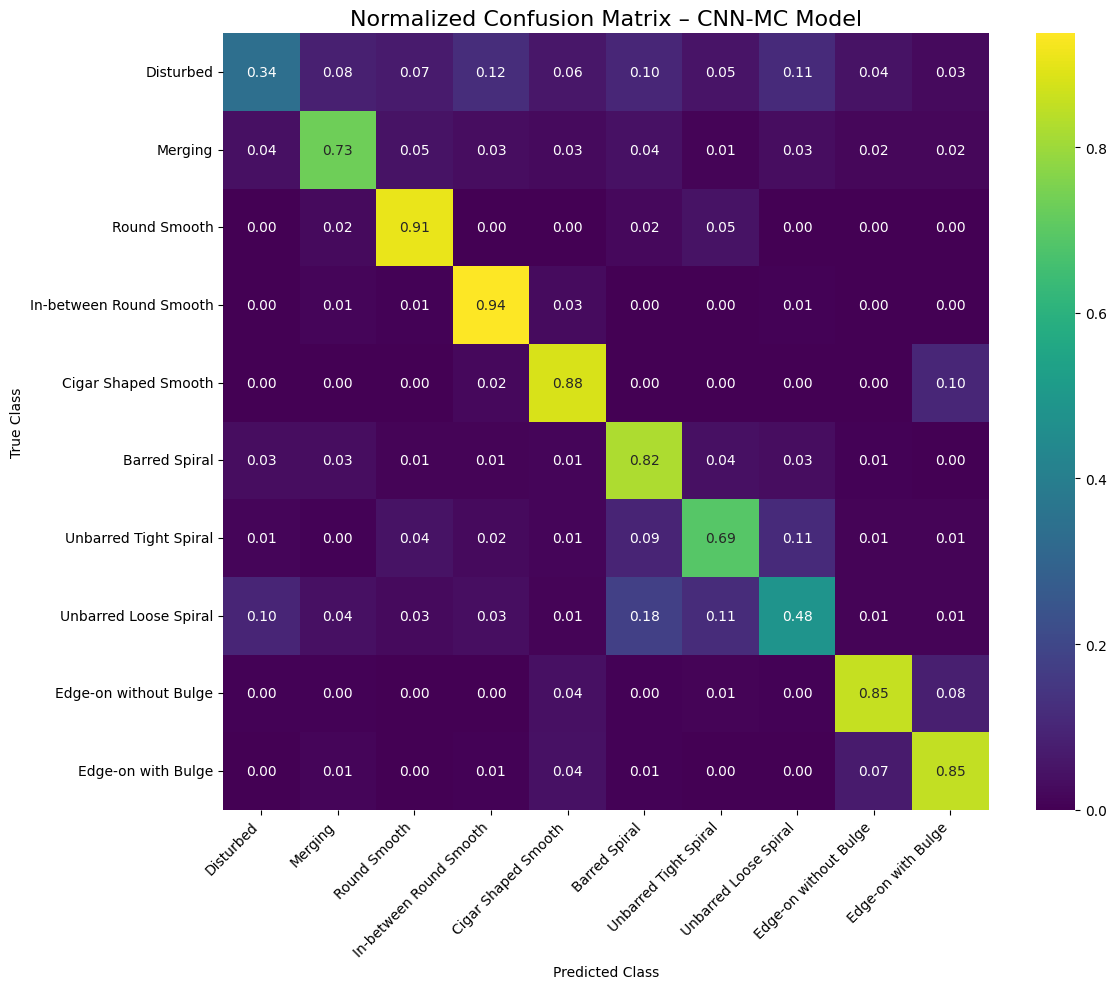

In [ ]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Normalized Confusion Matrix – CNN-MC Model", fontsize=16)
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
def mc_dropout_predict(model, dataset, n_samples=30, batch_size_predict=64):
    """
    Perform Bayesian inference using Monte Carlo Dropout.
    """
    # STEP1:Reconstitute full test arrays from batches

    imgs, labs = [], []

    for batch_imgs, batch_labs in dataset:
        imgs.append(batch_imgs.numpy())
        labs.append(batch_labs.numpy())

    imgs = np.concatenate(imgs, axis=0)   # (N, H, W, C)
    labs = np.concatenate(labs, axis=0)   # (N,)

    N = imgs.shape[0]
    print(f"Collected {N} evaluation samples.\n")

    # STEP2: Monte Carlo sampling loop

    all_preds_mc = [] # Renamed to avoid confusion with batch_preds

    for i in range(n_samples):
        if (i + 1) % 5 == 0 or i == 0:
            print(f"  Pass {i+1}/{n_samples} ...")

        # Process in batches within each MC sample
        batch_preds = []
        for j in range(0, N, batch_size_predict):
            end_idx = min(j + batch_size_predict, N)
            current_batch = imgs[j:end_idx]
            logits = model(current_batch, training=True)          # dropout active
            probs  = tf.nn.softmax(logits, axis=-1).numpy()
            batch_preds.append(probs)

        all_preds_mc.append(np.concatenate(batch_preds, axis=0)) # Concatenate batch predictions for this MC sample

    all_preds = np.array(all_preds_mc)  # (T, N, C)

    # STEP3: Bayesian predictive statistics

    # Predictive mean / variance
    mean_pred = np.mean(all_preds, axis=0)
    std_pred  = np.std(all_preds, axis=0)

    # Predictive entropy (total uncertainty)
    predictive_entropy = -np.sum(
        mean_pred * np.log(mean_pred + 1e-9), axis=1
    )
    # Aleatoric entropy (expected per-pass entropy)
    aleatoric_entropy = -np.mean(
        np.sum(all_preds * np.log(all_preds + 1e-9), axis=2),
        axis=0
    )

    # Epistemic uncertainty = Predictive - Aleatoric
    mutual_information = predictive_entropy - aleatoric_entropy

    # Variation ratio = 1 - p(most probable class)
    variation_ratio = 1 - np.max(mean_pred, axis=1)

    return {
        "mean_pred": mean_pred,
        "std_pred": std_pred,
        "predictive_entropy": predictive_entropy,
        "aleatoric_entropy": aleatoric_entropy,
        "mutual_information": mutual_information,
        "variation_ratio": variation_ratio,
        "y_true": labs,
        "all_preds": all_preds
    }

In [ ]:
results = mc_dropout_predict(model_a, test_ds, n_samples=30, batch_size_predict=BATCH_SIZE)

Collected 2634 evaluation samples.

  Pass 1/30 ...
  Pass 5/30 ...
  Pass 10/30 ...
  Pass 15/30 ...
  Pass 20/30 ...
  Pass 25/30 ...
  Pass 30/30 ...


In [ ]:
#  Final Predictions (Most Important)
mean_prediction = results['mean_pred']  # Shape: (n_galaxies, n_classes)
true_labels = results["y_true"]
predicted_labels = np.argmax(mean_prediction, axis=1)  # Predicted class for each galaxy
confidence_scores = np.max(mean_prediction, axis=1)     # Confidence for each prediction

print(f"FINAL PREDICTIONS:")
print(f"Predicted classes shape: {predicted_labels.shape}")
print(f"Confidence scores shape: {confidence_scores.shape}")
print(f"First 10 predictions: {predicted_labels[:10]}")
print(f"First 10 confidences: {confidence_scores[:10].round(3)}")

FINAL PREDICTIONS:
Predicted classes shape: (2634,)
Confidence scores shape: (2634,)
First 10 predictions: [8 4 7 3 7 8 4 5 6 3]
First 10 confidences: [0.664 0.783 0.414 0.862 0.531 0.676 0.735 0.917 0.429 0.682]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# step 1a:Compute Accuracy
mc_accuracy = accuracy_score(true_labels, predicted_labels)
print(f"MC Dropout Accuracy: {mc_accuracy:.4f}")

MC Dropout Accuracy: 0.7551


In [ ]:
# step 1b:Calculation of Precision, Recall, and F1-Score
# Per-class precision, recall, f1
precision_per_class = precision_score(true_labels, predicted_labels, average=None)
recall_per_class = recall_score(true_labels, predicted_labels, average=None)
f1_per_class = f1_score(true_labels, predicted_labels, average=None)

# Macro averaged scores
precision_macro = precision_score(true_labels, predicted_labels, average='macro')
recall_macro = recall_score(true_labels, predicted_labels, average='macro')
f1_macro = f1_score(true_labels, predicted_labels, average='macro')

# Print macro scores
print(f"Macro Precision: {precision_macro:.4f}")
print(f"Macro Recall: {recall_macro:.4f}")
print(f"Macro F1-score: {f1_macro:.4f}")

# Print per-class scores
for i, class_name in enumerate(class_names):
    print(f"{class_name}: Precision={precision_per_class[i]:.4f}, Recall={recall_per_class[i]:.4f}, F1={f1_per_class[i]:.4f}")

Macro Precision: 0.7156
Macro Recall: 0.7558
Macro F1-score: 0.7259
Disturbed: Precision=0.4113, Recall=0.3648, F1=0.3867
Merging: Precision=0.7162, Recall=0.7891, F1=0.7509
Round Smooth: Precision=0.8900, Recall=0.8810, F1=0.8855
In-between Round Smooth: Precision=0.8642, Recall=0.9241, F1=0.8931
Cigar Shaped Smooth: Precision=0.4545, Recall=0.9000, F1=0.6040
Barred Spiral: Precision=0.7187, Recall=0.7730, F1=0.7448
Unbarred Tight Spiral: Precision=0.6690, Recall=0.7159, F1=0.6916
Unbarred Loose Spiral: Precision=0.7148, Recall=0.5051, F1=0.5919
Edge-on without Bulge: Precision=0.8564, Recall=0.8439, F1=0.8501
Edge-on with Bulge: Precision=0.8607, Recall=0.8607, F1=0.8607


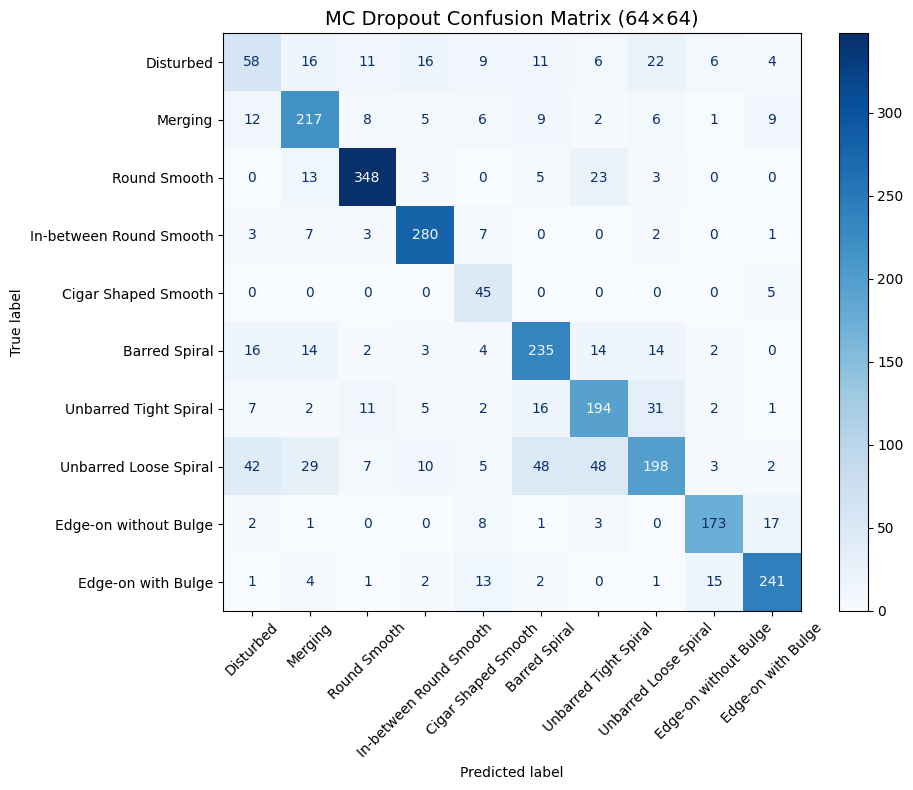

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels, predicted_labels)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
plt.title("MC Dropout Confusion Matrix (64×64)", fontsize=14)
plt.tight_layout()
plt.show()


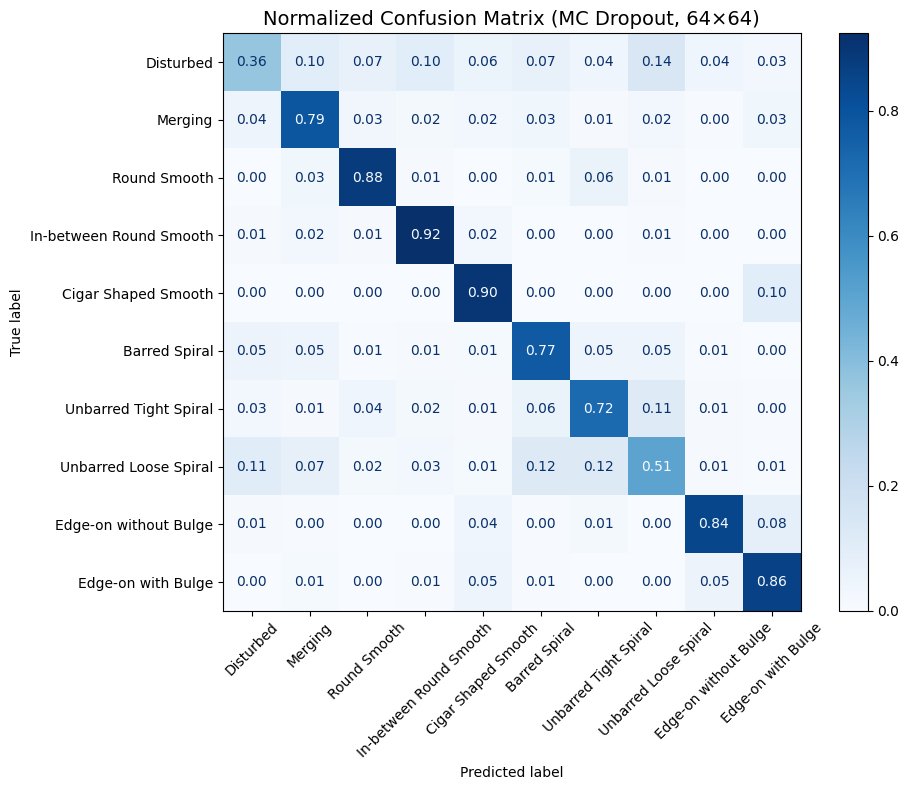

In [ ]:
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax, values_format=".2f")
plt.title("Normalized Confusion Matrix (MC Dropout, 64×64)", fontsize=14)
plt.tight_layout()
plt.show()


Class 0: Accuracy = 0.365, Mean Entropy = 1.285
Class 1: Accuracy = 0.789, Mean Entropy = 0.989
Class 2: Accuracy = 0.881, Mean Entropy = 0.704
Class 3: Accuracy = 0.924, Mean Entropy = 0.881
Class 4: Accuracy = 0.900, Mean Entropy = 0.838
Class 5: Accuracy = 0.773, Mean Entropy = 0.964
Class 6: Accuracy = 0.716, Mean Entropy = 1.160
Class 7: Accuracy = 0.505, Mean Entropy = 1.360
Class 8: Accuracy = 0.844, Mean Entropy = 0.698
Class 9: Accuracy = 0.861, Mean Entropy = 0.713


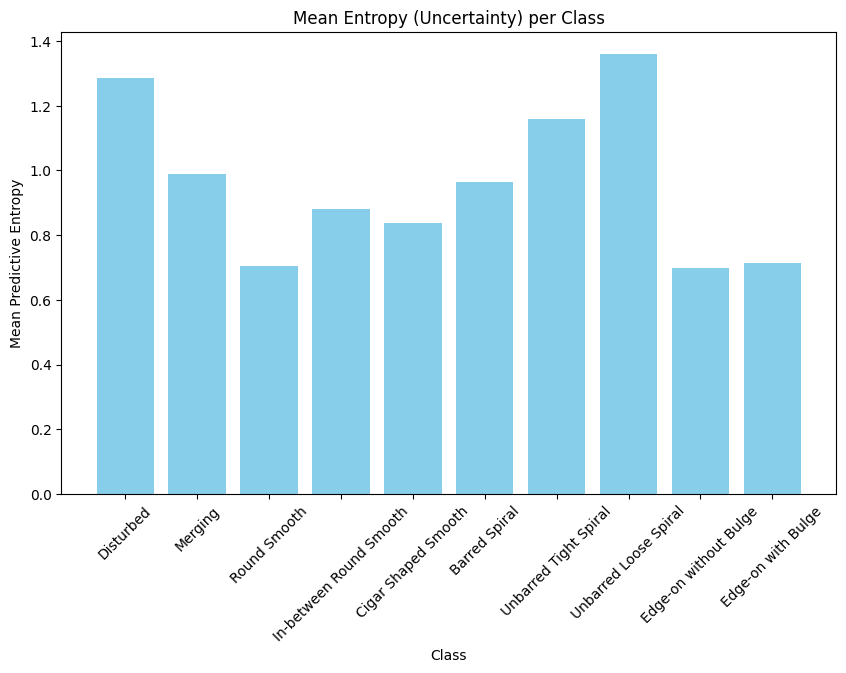

In [ ]:
# step 1d:Per-class accuracy and entropy(uncertainty) comparison
num_classes = len(np.unique(true_labels))
per_class_accuracy = []
mean_entropies = []

# Define uncertainty using the results from mc_dropout_predict
uncertainty = results['predictive_entropy']

for class_idx in range(num_classes):
    class_mask = true_labels == class_idx

    # Calculate per-class accuracy
    acc = np.mean(predicted_labels[class_mask] == true_labels[class_mask])
    per_class_accuracy.append(acc)
    #print(f"Class {class_idx} accuracy: {acc:.3f}")

    # Calculate mean predictive entropy
    mean_entropy = uncertainty[class_mask].mean()
    mean_entropies.append(mean_entropy)
    print(f"Class {class_idx}: Accuracy = {acc:.3f}, Mean Entropy = {mean_entropy:.3f}")


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Mean Predictive Entropy')
plt.title('Mean Entropy (Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

In [ ]:
#  step e: Detailed Classification Report
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)


                         precision    recall  f1-score   support

              Disturbed       0.41      0.36      0.39       159
                Merging       0.72      0.79      0.75       275
           Round Smooth       0.89      0.88      0.89       395
In-between Round Smooth       0.86      0.92      0.89       303
    Cigar Shaped Smooth       0.45      0.90      0.60        50
          Barred Spiral       0.72      0.77      0.74       304
  Unbarred Tight Spiral       0.67      0.72      0.69       271
  Unbarred Loose Spiral       0.71      0.51      0.59       392
  Edge-on without Bulge       0.86      0.84      0.85       205
     Edge-on with Bulge       0.86      0.86      0.86       280

               accuracy                           0.76      2634
              macro avg       0.72      0.76      0.73      2634
           weighted avg       0.76      0.76      0.75      2634



In [ ]:
#2. Uncertainty Quantification Metrics(Quantify model/data uncertainty/MC Dropout)
# Predictive Entropy(Measures total uncertainty in prediction)
uncertainty = results['predictive_entropy']      # Total uncertainty(uncertainty/entropy)

# Mutual Information (Epistemic Uncertainty)
mutual_info = results['mutual_information']      # Model uncertainty/Epistemic uncertainty

# Aleatoric Uncertainty(noise inherent in input data, irreducible by more data)
aleatoric = results['aleatoric_entropy']     # Data uncertainty/Aleatoric uncertainty

print(f"\n UNCERTAINTY METRICS:")
print(f"Predictive entropy shape: {uncertainty.shape}")
print(f"Mutual information shape: {mutual_info.shape}")
print(f"Aleatoric uncertainty shape: {aleatoric.shape}")

print(f"\n UNCERTAINTY STATISTICS:")
print(f"Average predictive entropy: {np.mean(uncertainty):.4f}")
print(f"Average mutual information: {np.mean(mutual_info):.4f}")
print(f"Average aleatoric uncertainty: {np.mean(aleatoric):.4f}")
print(f"Uncertainty range: [{uncertainty.min():.4f}, {uncertainty.max():.4f}]")


 UNCERTAINTY METRICS:
Predictive entropy shape: (2634,)
Mutual information shape: (2634,)
Aleatoric uncertainty shape: (2634,)

 UNCERTAINTY STATISTICS:
Average predictive entropy: 0.9668
Average mutual information: 0.1457
Average aleatoric uncertainty: 0.8211
Uncertainty range: [0.0427, 1.9606]


Found 185 samples with high uncertainty and low confidence.


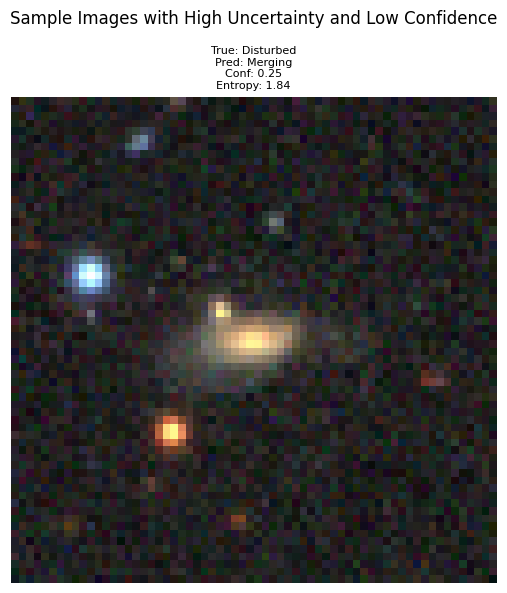

In [ ]:
# Define thresholds for high uncertainty and low confidence
# You can adjust these thresholds based on the distributions observed in the plots
uncertainty_threshold = np.percentile(results['predictive_entropy'], 90) # e.g., top 10% most uncertain
confidence_threshold = np.percentile(confidence_scores, 10) # e.g., bottom 10% least confident

# Find indices of samples meeting the criteria
high_uncertainty_low_confidence_indices = np.where(
    (results['predictive_entropy'] > uncertainty_threshold) &
    (confidence_scores < confidence_threshold)
)[0]

print(f"Found {len(high_uncertainty_low_confidence_indices)} samples with high uncertainty and low confidence.")

# Display a few sample images from these indices
num_samples_to_show = min(10, len(high_uncertainty_low_confidence_indices)) # Display up to 10 samples

if num_samples_to_show > 0:
    plt.figure(figsize=(15, 6))
    for i in range(num_samples_to_show):
        idx = high_uncertainty_low_confidence_indices[i]
        # Corrected: use 'test_images' instead of 'images_test'
        plt.imshow(test_images[idx][:, :, :3]) # Display RGB channels only for visualization
        plt.title(f"True: {class_names[true_labels[idx]]}\nPred: {class_names[predicted_labels[idx]]}\nConf: {confidence_scores[idx]:.2f}\nEntropy: {results['predictive_entropy'][idx]:.2f}", fontsize=8)
        plt.axis('off')
    plt.suptitle('Sample Images with High Uncertainty and Low Confidence')
    plt.tight_layout()
    plt.show()
else:
    print("No samples found meeting the criteria.")

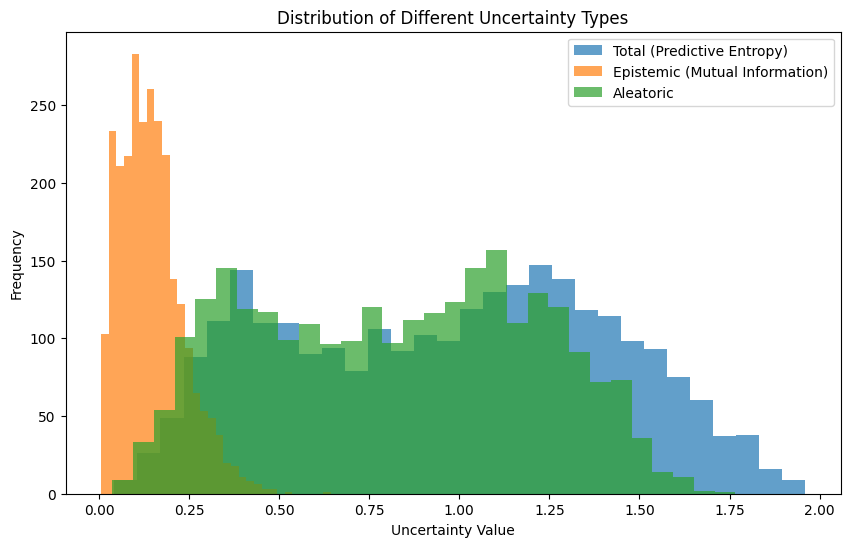

In [ ]:
# 3. Visualizations Related to Uncertainty
# Step 3a: Histogram of Uncertainty Distributions( all three)
plt.figure(figsize=(10,6))
plt.hist(uncertainty, bins=30, alpha=0.7, label='Total (Predictive Entropy)')
plt.hist(mutual_info, bins=30, alpha=0.7, label='Epistemic (Mutual Information)')
plt.hist(aleatoric, bins=30, alpha=0.7, label='Aleatoric')
plt.xlabel("Uncertainty Value")
plt.ylabel("Frequency")
plt.title("Distribution of Different Uncertainty Types")
plt.legend()
plt.show()

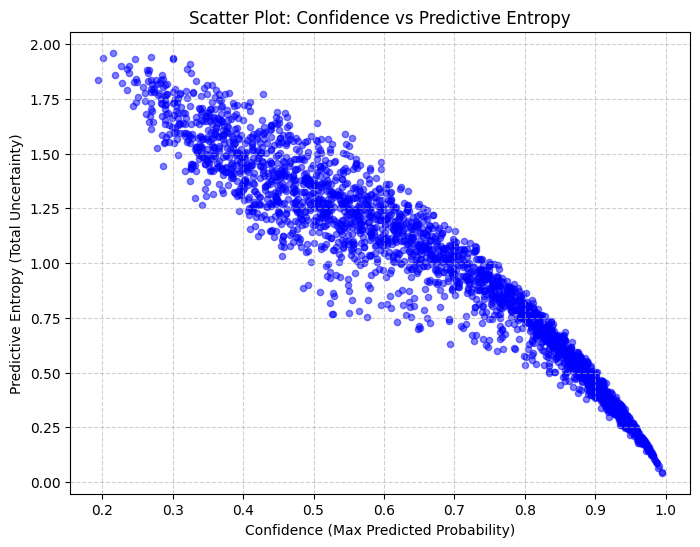

In [ ]:
# step 3b: Scatter plot: Confidence vs Predictive Entropy
plt.figure(figsize=(8,6))
plt.scatter(confidence_scores, uncertainty, alpha=0.5, s=20, c='blue')
plt.xlabel('Confidence (Max Predicted Probability)')
plt.ylabel('Predictive Entropy (Total Uncertainty)')
plt.title('Scatter Plot: Confidence vs Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

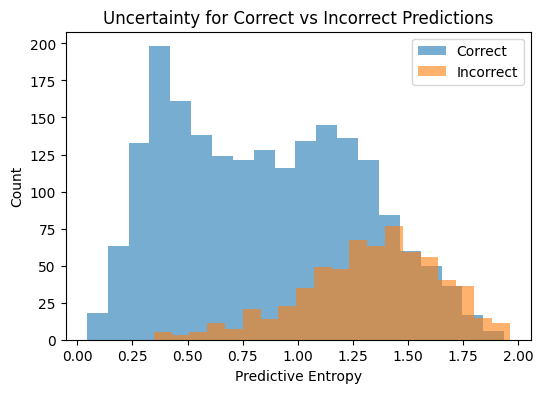

In [ ]:
# Step 3c: Compare Correct vs Incorrect Predictions
correct = (predicted_labels == true_labels)
plt.figure(figsize=(6,4))
plt.hist(uncertainty[correct], bins=20, alpha=0.6, label='Correct')
plt.hist(uncertainty[~correct], bins=20, alpha=0.6, label='Incorrect')
plt.xlabel('Predictive Entropy')
plt.ylabel('Count')
plt.legend()
plt.title('Uncertainty for Correct vs Incorrect Predictions')
plt.show()

/tmp/ipython-input-1080141530.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([uncertainty[correct], uncertainty[~correct]], labels=['Correct', 'Incorrect'],patch_artist=True,


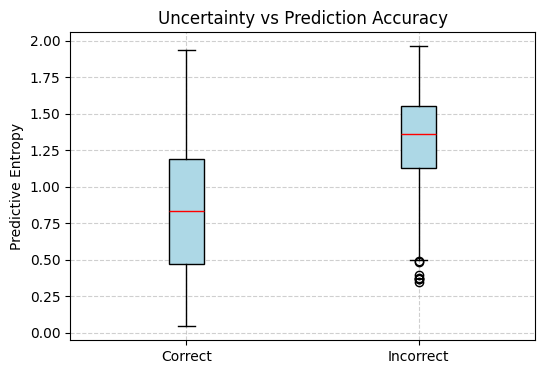

In [ ]:
# Boxplot: Uncertainty vs Correctness
correct = (predicted_labels == true_labels)
plt.figure(figsize=(6,4))
plt.boxplot([uncertainty[correct], uncertainty[~correct]], labels=['Correct', 'Incorrect'],patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red'))
plt.title('Uncertainty vs Prediction Accuracy')
plt.ylabel('Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


predictions shape: (30, 2634, 10)
Average Variation Ratio: 0.1708807896735004


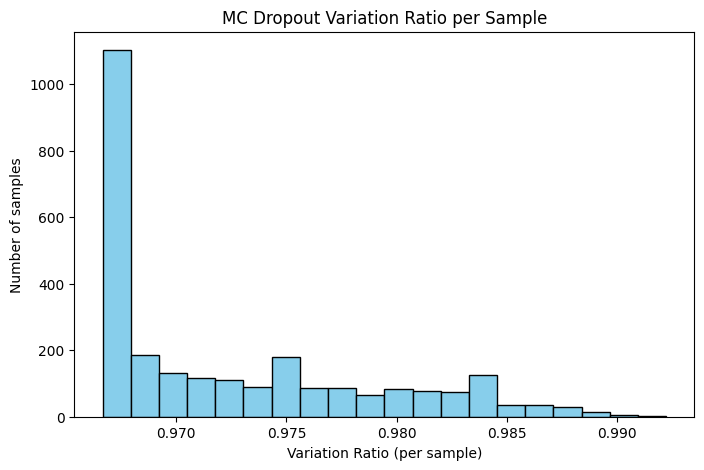

In [ ]:
# step 3d: Variation Ratio
# predictions: shape (num_mc_samples, num_test_samples, num_classes)
predictions = results['all_preds']
print(f"predictions shape: {predictions.shape}")
mc_classes = np.argmax(predictions, axis=2)  # shape: (num_mc_samples, num_test_samples)

# For each test sample, find the most common predicted class count
mode_counts = np.apply_along_axis(lambda x: np.bincount(x, minlength=num_classes).max(), axis=0, arr=mc_classes)

variation_ratio = 1 - (mode_counts /predictions.shape[0])
print("Average Variation Ratio:", variation_ratio.mean())

# Compute variation ratio per test sample
num_test_samples = predictions.shape[1]
num_mc_samples = predictions.shape[0]
variation_ratio_per_sample = 1 - np.array([
    np.mean(mc_classes[:, i] == np.bincount(mc_classes[:, i]).argmax()) / num_mc_samples
    for i in range(num_test_samples)
])

# Histogram of variation ratios
plt.figure(figsize=(8,5))
plt.hist(variation_ratio_per_sample, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Variation Ratio (per sample)')
plt.ylabel('Number of samples')
plt.title('MC Dropout Variation Ratio per Sample')
plt.show()

Class 0 entropy: 1.2847042
Class 1 entropy: 0.98878795
Class 2 entropy: 0.7042871
Class 3 entropy: 0.8810959
Class 4 entropy: 0.83761096
Class 5 entropy: 0.96408886
Class 6 entropy: 1.1598945
Class 7 entropy: 1.3604087
Class 8 entropy: 0.6981246
Class 9 entropy: 0.7125599


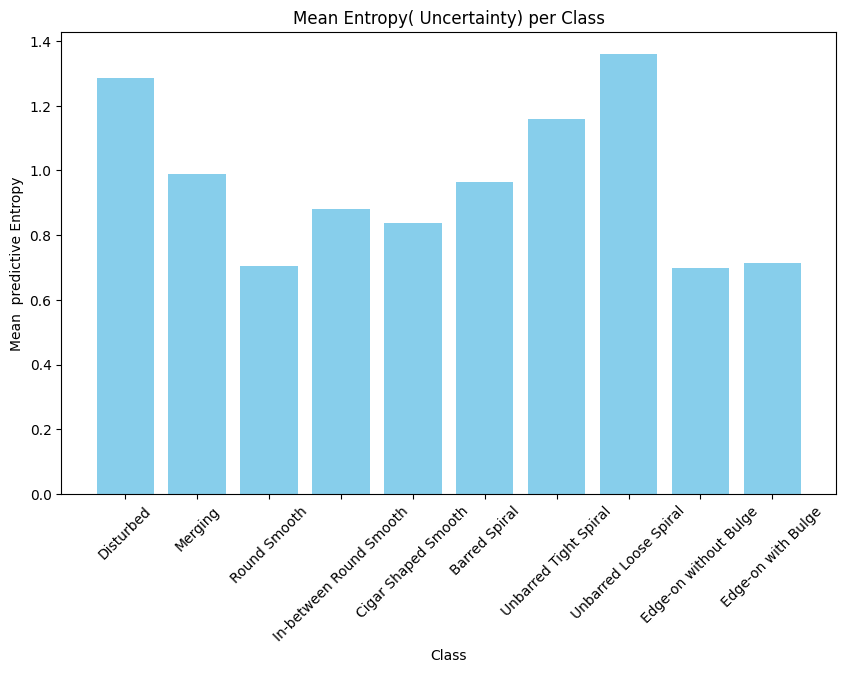

In [ ]:
# Per-Class Uncertainty(extra)

mean_entropies = []
for class_idx in range(num_classes):
    class_mask = (true_labels == class_idx)
    mean_entropy = uncertainty[class_mask].mean()
    mean_entropies.append(mean_entropy)
    print(f"Class {class_idx} entropy:", uncertainty[class_mask].mean())


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies, color = 'skyblue')
plt.xlabel('Class')
plt.ylabel('Mean  predictive Entropy')
plt.title('Mean Entropy( Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

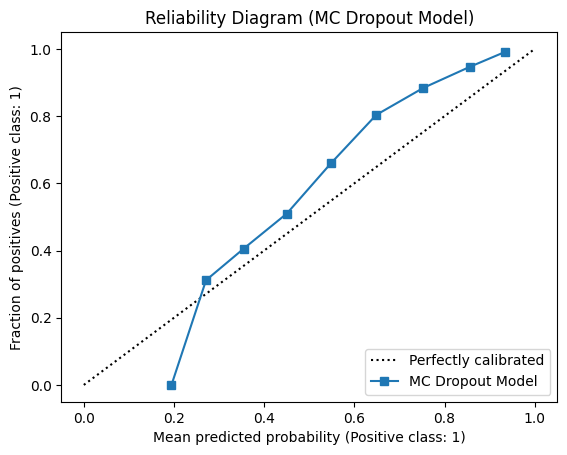

In [ ]:
# Step 4a: Reliability Diagram (Calibration Plot)
from sklearn.calibration import CalibrationDisplay
# Create true/false correctness per sample
correct = (predicted_labels == true_labels)

# Plot reliability diagram
disp = CalibrationDisplay.from_predictions(
    y_true=correct,
    y_prob=confidence_scores,
    n_bins=10,
    strategy='uniform',
    name='MC Dropout Model'
)
plt.title("Reliability Diagram (MC Dropout Model)")
plt.show()

In [ ]:
# Step 4b: Compute Expected Calibration Error (ECE)
def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Compute Expected Calibration Error (ECE)."""
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    binids = np.digitize(y_prob, bins) - 1
    ece = 0.0

    for i in range(n_bins):
        bin_mask = binids == i
        if np.sum(bin_mask) > 0:
            bin_acc = np.mean(y_true[bin_mask])
            bin_conf = np.mean(y_prob[bin_mask])
            ece += np.abs(bin_acc - bin_conf) * np.sum(bin_mask) / len(y_true)
    return ece

# Compute ECE for MC Dropout model
ece_score = expected_calibration_error(correct, confidence_scores, n_bins=10)
print(f"Expected Calibration Error (ECE): {ece_score:.4f}")

Expected Calibration Error (ECE): 0.0914


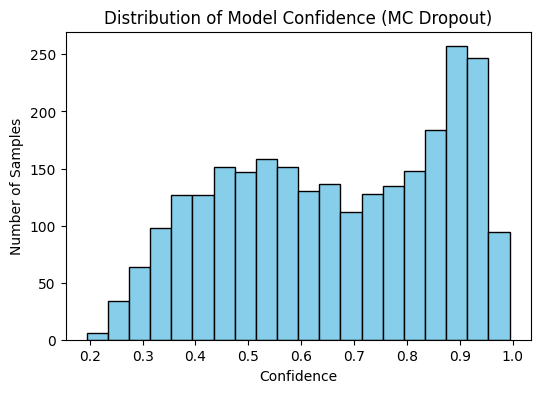

In [ ]:
# 4cHistogram of Confidence(optional)
plt.figure(figsize=(6,4))
plt.hist(confidence_scores, bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Model Confidence (MC Dropout)')
plt.xlabel('Confidence')
plt.ylabel('Number of Samples')
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import label_binarize

def get_probs_and_labels_cnn(model, test_ds, num_classes=10, mc_dropout=False, T=1):
    """
    Returns:
        y_true_onehot → (N, num_classes) one-hot labels
        y_prob        → (N, num_classes) predicted probabilities
    Compatible with late-fusion 2-input models.
    """
    all_probs = []
    all_labels = []

    for features, labels in test_ds:
        # features = {"image_input": img_batch, "redshift_input": z_batch}
        labels_np = labels.numpy()
        all_labels.append(labels_np)


        # Classical single forward-pass

        if not mc_dropout:
            logits = model(features, training=False)
            probs = tf.nn.softmax(logits, axis=-1).numpy()
            all_probs.append(probs)


        # Monte-Carlo Dropout prediction

        else:
            mc_probs = []
            for _ in range(T):
                logits = model(features, training=True)  # dropout ON
                probs = tf.nn.softmax(logits, axis=-1).numpy()
                mc_probs.append(probs)

            mc_probs = np.mean(mc_probs, axis=0)        # average over T samples
            all_probs.append(mc_probs)

    # Combine batches → shape (N, num_classes)
    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs,  axis=0)

    # Convert to one-hot for ROC/AUC
    y_true_onehot = label_binarize(y_true, classes=np.arange(num_classes))

    return y_true_onehot, y_prob


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_auc_cnn(y_true_onehot, y_prob, model_name="CNN MC"):
    num_classes = y_true_onehot.shape[1]

    fpr = {}
    tpr = {}
    roc_auc = {}

    # One-vs-rest ROC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_onehot.ravel(), y_prob.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    tpr_list = []

    for i in range(num_classes):
        tpr_list.append(np.interp(fpr_grid, fpr[i], tpr[i]))

    mean_tpr = np.mean(tpr_list, axis=0)
    roc_auc["macro"] = auc(fpr_grid, mean_tpr)

    # Plot
    plt.figure(figsize=(10, 8))

    plt.plot(
        fpr_grid,
        mean_tpr,
        label=f"Macro-average ROC (AUC = {roc_auc['macro']:.4f})",
        linewidth=2,
    )

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
        linewidth=2,
    )

    # Diagonal baseline
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

    plt.title(f"ROC–AUC Curve – {model_name}", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    return roc_auc


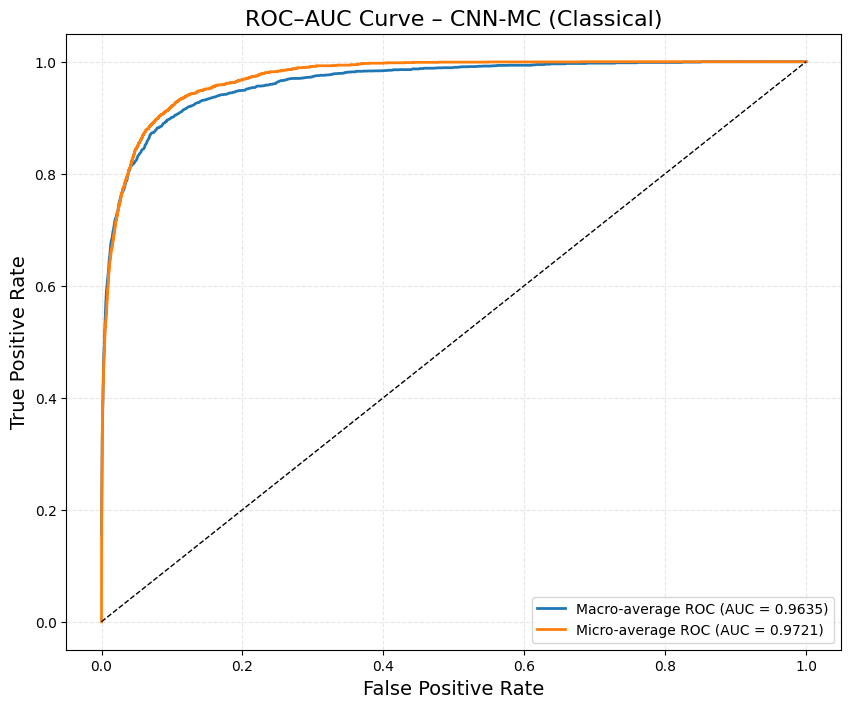

{0: np.float64(0.8578095419604853), 1: np.float64(0.9737423407453081), 2: np.float64(0.9900509382013897), 3: np.float64(0.9936938352779936), 4: np.float64(0.9930650154798762), 5: np.float64(0.954939857691439), 6: np.float64(0.9611398356895123), 7: np.float64(0.928523070691256), 8: np.float64(0.9919308357348704), 9: np.float64(0.9900321640975847), 'micro': np.float64(0.9720579887729983), 'macro': np.float64(0.9635058104500693)}


In [ ]:
y_true_onehot_cnn, y_prob_cnn = get_probs_and_labels_cnn(
    model_a, test_ds, mc_dropout=False
)

roc_scores_cnn = plot_roc_auc_cnn(
    y_true_onehot_cnn,
    y_prob_cnn,
    model_name="CNN-MC (Classical)"
)

print(roc_scores_cnn)


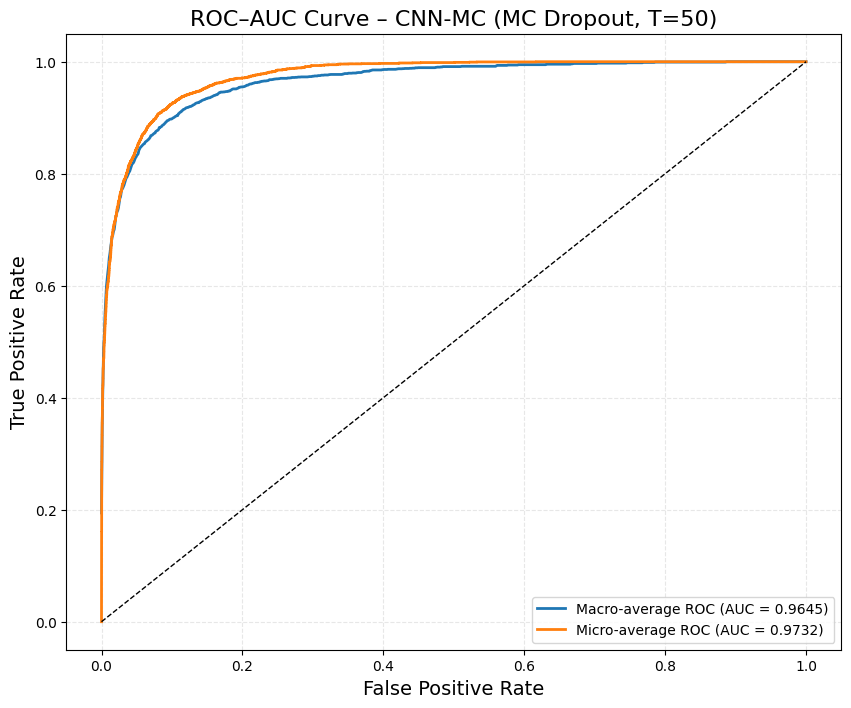

{0: np.float64(0.8660771234356139), 1: np.float64(0.978893984353925), 2: np.float64(0.9916667137793205), 3: np.float64(0.9937221521379936), 4: np.float64(0.9940944272445821), 5: np.float64(0.9522278066410661), 6: np.float64(0.9616598451215151), 7: np.float64(0.9251010395237489), 8: np.float64(0.9921738344596291), 9: np.float64(0.9895451511105716), 'micro': np.float64(0.9731817267218185), 'macro': np.float64(0.9645309454028894)}


In [ ]:
y_true_onehot_cnn_mc, y_prob_cnn_mc = get_probs_and_labels_cnn(
    model_a, test_ds, mc_dropout=True, T=50
)

roc_scores_cnn_mc = plot_roc_auc_cnn(
    y_true_onehot_cnn_mc,
    y_prob_cnn_mc,
    model_name="CNN-MC (MC Dropout, T=50)"
)

print(roc_scores_cnn_mc)


In [ ]:
# Model 2: Vit_MC
def build_vit_mc(
        img_shape=(64, 64, 4),
        num_classes=10,
        patch_size=8,
        embed_dim=192,
        depth=4,
        num_heads=4,
        mlp_dim=256,
        dropout_rate=0.1,
        head_dropout=0.3):

    # 1) Input
    inputs = layers.Input(shape=img_shape, name="image_input")
    H, W, C = img_shape
    assert H % patch_size == 0 and W % patch_size == 0, "H,W must be divisible by patch_size"

    num_patches = (H // patch_size) * (W // patch_size)

    # 2) Patch embedding: Conv2D (B, N, D)
    x = layers.Conv2D(
        filters=embed_dim,
        kernel_size=patch_size,
        strides=patch_size,
        padding="valid",
        name="patch_embedding",
    )(inputs)                            # (B, H/ps, W/ps, D)
    x = layers.Reshape((num_patches, embed_dim))(x)  # (B, N, D)

    # 3) Learnable CLS Token
    cls_token_var = tf.Variable(
        tf.random.truncated_normal((1, 1, embed_dim), stddev=0.02),
        name="cls_token_var",
        trainable=True
    )
    cls = layers.Lambda(
        lambda inputs_x: tf.broadcast_to(cls_token_var, [tf.shape(inputs_x)[0], 1, embed_dim]),
        name="cls_token_broadcast"
    )(x)
    x = layers.Concatenate(axis=1)([cls, x])  # (B, 1+N, D)

    # 4) Learnable Positional Embedding
    pos_emb = tf.Variable(
        tf.random.truncated_normal((1, 1 + num_patches, embed_dim), stddev=0.02),
        name="pos_embedding",
        trainable=True
    )
    x = layers.Add()([x, pos_emb])
    x = layers.Dropout(dropout_rate)(x)

    # 5) Transformer encoder blocks (pre-norm)
    for i in range(depth):
        # Multi-Head Self-Attention block
        shortcut = x
        x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"encoder_norm1_{i}")(x)
        attn_out = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim // num_heads,
            dropout=dropout_rate,
            name=f"encoder_mhsa_{i}",
        )(x_norm, x_norm)   # NO training=True here
        x = layers.Add(name=f"encoder_attn_add_{i}")([shortcut, attn_out])

        # MLP block
        shortcut = x
        x_norm = layers.LayerNormalization(epsilon=1e-6, name=f"encoder_norm2_{i}")(x)
        mlp = layers.Dense(mlp_dim, activation="gelu", name=f"encoder_mlp1_{i}")(x_norm)
        mlp = layers.Dropout(dropout_rate, name=f"encoder_mlp_drop1_{i}")(mlp)
        mlp = layers.Dense(embed_dim, name=f"encoder_mlp2_{i}")(mlp)
        mlp = layers.Dropout(dropout_rate, name=f"encoder_mlp_drop2_{i}")(mlp)
        x = layers.Add(name=f"encoder_mlp_add_{i}")([shortcut, mlp])

    # 6) CLS token representation
    cls_token_out = layers.Lambda(lambda t: t[:, 0], name="cls_extract")(x)  # (B, D)

    # 7) Classification head with MC-Dropout
    #    (MC comes from calling model(..., training=True) at inference)
    h = layers.LayerNormalization(epsilon=1e-6, name="head_ln")(cls_token_out)
    h = layers.Dense(256, activation="gelu", name="head_dense1")(h)
    h = layers.Dropout(head_dropout, name="head_drop1")(h)      # MC-Dropout location
    h = layers.Dense(128, activation="gelu", name="head_dense2")(h)
    h = layers.Dropout(head_dropout, name="head_drop2")(h)      # MC-Dropout location

    # LOGITS (no softmax here)
    logits = layers.Dense(num_classes, name="logits")(h)

    model = models.Model(inputs, logits, name="ViT_MC_4ch")
    return model

In [ ]:
# 1) Learning Rate Schedule
initial_lr = 1e-4
warmup_epochs = 5
total_epochs = 120
steps_per_epoch = tf.data.experimental.cardinality(train_ds).numpy()
print("Steps per epoch:", steps_per_epoch)

warmup_steps = warmup_epochs * steps_per_epoch
total_steps = total_epochs * steps_per_epoch

class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, initial_lr, warmup_steps, total_steps):
        super().__init__()
        self.initial_lr = initial_lr
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps

        self.cosine_decay_schedule = tf.keras.optimizers.schedules.CosineDecay(
            initial_learning_rate=initial_lr,
            decay_steps=(total_steps - warmup_steps)
        )

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)

        return tf.cond(
            step < warmup_steps,
            lambda: self.initial_lr * (step / warmup_steps),
            lambda: self.cosine_decay_schedule(step - warmup_steps)
        )

    def get_config(self):
        return {
            "initial_lr": self.initial_lr,
            "warmup_steps": self.warmup_steps,
            "total_steps": self.total_steps,
        }
lr_schedule = CustomSchedule(initial_lr, warmup_steps, total_steps)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4,
    beta_1=0.9,
    beta_2=0.999,
    epsilon=1e-8,
    clipnorm=1.0
)


Steps per epoch: 289


In [ ]:
#4 Build model
model_b = build_vit_mc(img_shape=(64,64,4), num_classes=10)
model_b.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"],
)


#model_b.summary()


In [ ]:
# Callbacks (EarlyStopping, checkpoint)
callbacks_c = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=15,
        min_delta=0.003,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ModelCheckpoint(
        filepath='models/modelB_vit_mc_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.CSVLogger(
        'training_logs_vit_mc.csv'
    )

]


In [ ]:
history_b = model_b.fit(
    train_ds,
    epochs=120,
    validation_data=val_ds,
    callbacks=callbacks_c,
    verbose=1
    )

Epoch 1/120
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.1069 - loss: 2.4896
Epoch 1: val_accuracy improved from -inf to 0.15799, saving model to models/modelB_vit_mc_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 111s 188ms/step - accuracy: 0.1069 - loss: 2.4893 - val_accuracy: 0.1580 - val_loss: 2.2249
Epoch 2/120
287/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1294 - loss: 2.3004
Epoch 2: val_accuracy improved from 0.15799 to 0.17622, saving model to models/modelB_vit_mc_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.1294 - loss: 2.3003 - val_accuracy: 0.1762 - val_loss: 2.2523
Epoch 3/120
286/289 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1461 - loss: 2.2719
Epoch 3: val_accuracy improved from 0.17622 to 0.18192, saving model to models/modelB_vit_mc_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.1461 - loss: 2.2718 - val_accuracy: 0.1819 - val_loss: 2.2058
Epoch 4/120
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1

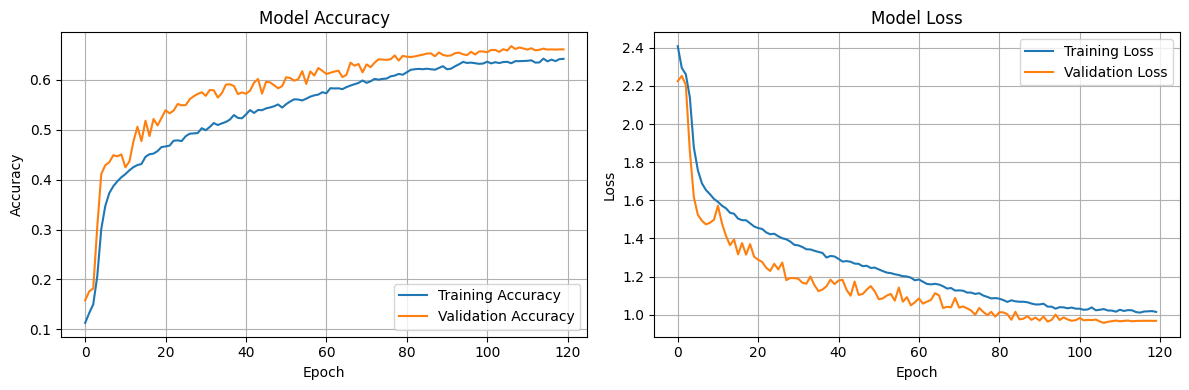

In [ ]:
def plot_training_history(history_b):
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history_b.history['accuracy'], label='Training Accuracy')
    ax1.plot(history_b.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history_b.history['loss'], label='Training Loss')
    ax2.plot(history_b.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history_b)


In [ ]:
# Classical Evaluation (Non-Bayesian)
# Standard test evaluation
test_loss, test_acc = model_b.evaluate(test_ds, verbose=1)

print(f"Test Accuracy (Classical): {test_acc:.4f}")
print(f"Test Loss       (Classical): {test_loss:.4f}")

42/42 ━━━━━━━━━━━━━━━━━━━━ 10s 253ms/step - accuracy: 0.6543 - loss: 0.9811
Test Accuracy (Classical): 0.6591
Test Loss       (Classical): 0.9613


In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score

def get_classical_predictions_mc(model, test_ds):
    all_preds = []
    all_labels = []

    for imgs, labels in test_ds:
        logits = model(imgs, training=False)      # disable dropout
        probs  = tf.nn.softmax(logits, axis=-1)   # convert logits → probabilities

        all_preds.append(probs.numpy())
        all_labels.append(labels.numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    y_pred_vit = np.argmax(all_preds, axis=1)
    y_true_vit= all_labels

    return y_true_vit, y_pred_vit


In [ ]:
y_true_vit, y_pred_vit = get_classical_predictions_mc(model_b, test_ds)

accuracy  = accuracy_score(y_true_vit, y_pred_vit)
precision = precision_score(y_true_vit, y_pred_vit, average='macro')
recall    = recall_score(y_true_vit, y_pred_vit, average='macro')
f1        = f1_score(y_true_vit, y_pred_vit, average='macro')

print("Classical Model Evaluation (No MC Dropout)")
print("-------------------------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Classical Model Evaluation (No MC Dropout)
-------------------------------------------
Accuracy : 0.6595
Precision: 0.6276
Recall   : 0.6621
F1-score : 0.6270


In [ ]:
print("\nClassification Report (Macro averaged):")
print(classification_report(y_true_vit, y_pred_vit, target_names=class_names))



Classification Report (Macro averaged):
                         precision    recall  f1-score   support

              Disturbed       0.43      0.35      0.39       159
                Merging       0.72      0.59      0.65       275
           Round Smooth       0.82      0.89      0.85       395
In-between Round Smooth       0.73      0.82      0.77       303
    Cigar Shaped Smooth       0.28      0.78      0.41        50
          Barred Spiral       0.59      0.45      0.51       304
  Unbarred Tight Spiral       0.52      0.73      0.61       271
  Unbarred Loose Spiral       0.59      0.43      0.50       392
  Edge-on without Bulge       0.80      0.86      0.83       205
     Edge-on with Bulge       0.80      0.73      0.77       280

               accuracy                           0.66      2634
              macro avg       0.63      0.66      0.63      2634
           weighted avg       0.67      0.66      0.66      2634



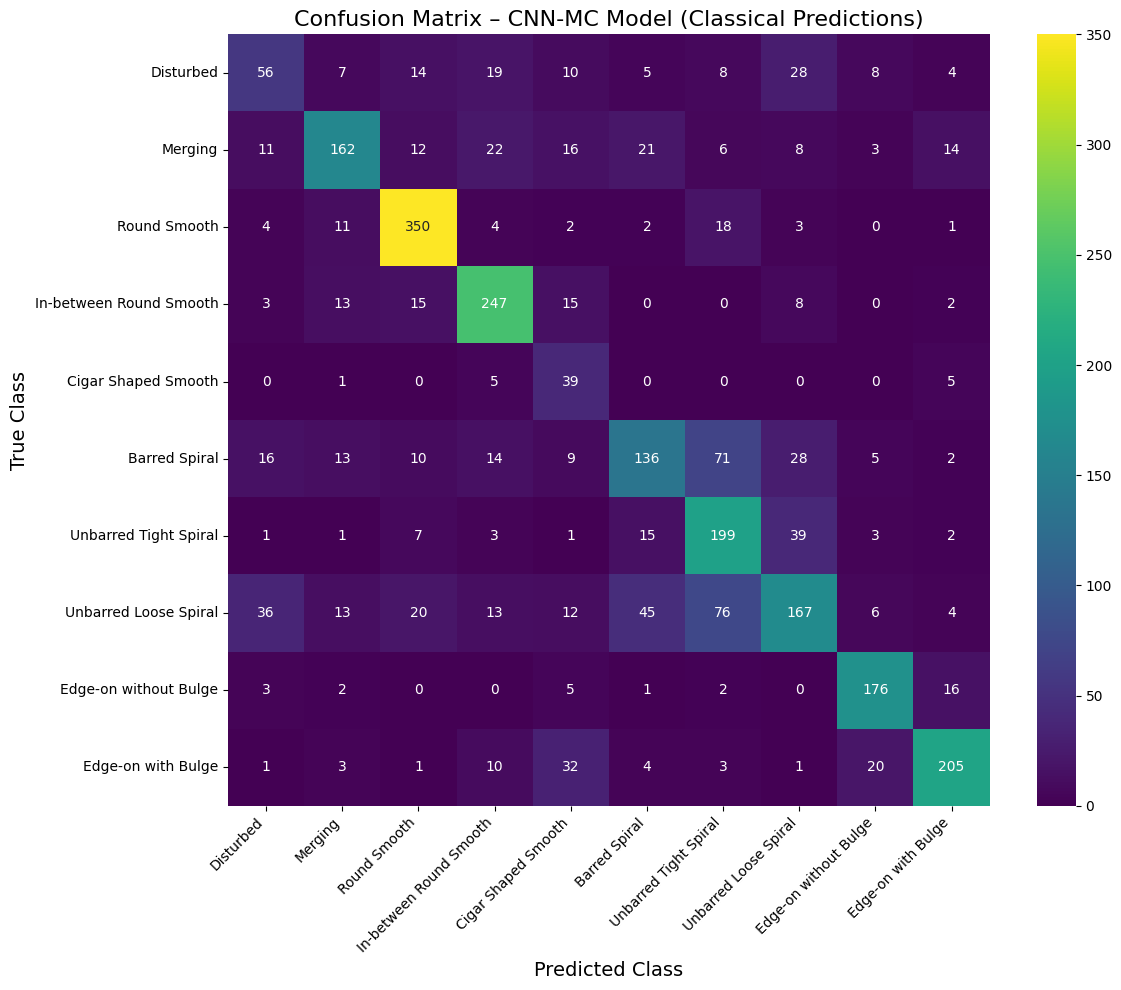

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_true_vit, y_pred_vit)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,        # show numbers
    fmt="d",           # integer formatting
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix – CNN-MC Model (Classical Predictions)", fontsize=16)
plt.xlabel("Predicted Class", fontsize=14)
plt.ylabel("True Class", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
def mc_dropout_predict_vit(model, dataset, n_samples=30, batch_size_predict=64):
    """
    Perform Bayesian inference using Monte Carlo Dropout.
    """
    # STEP1:Reconstitute full test arrays from batches

    imgs, labs = [], []

    for batch_imgs, batch_labs in dataset:
        imgs.append(batch_imgs.numpy())
        labs.append(batch_labs.numpy())

    imgs = np.concatenate(imgs, axis=0)   # (N, H, W, C)
    labs = np.concatenate(labs, axis=0)   # (N,)

    N = imgs.shape[0]
    print(f"Collected {N} evaluation samples.\n")

    # STEP2: Monte Carlo sampling loop

    all_preds_mc_vit = [] # Renamed to avoid confusion with batch_preds

    for i in range(n_samples):
        if (i + 1) % 5 == 0 or i == 0:
            print(f"  Pass {i+1}/{n_samples} ...")

        # Process in batches within each MC sample
        batch_preds = []
        for j in range(0, N, batch_size_predict):
            end_idx = min(j + batch_size_predict, N)
            current_batch = imgs[j:end_idx]
            logits = model(current_batch, training=True)          # dropout active
            probs  = tf.nn.softmax(logits, axis=-1).numpy()
            batch_preds.append(probs)

        all_preds_mc_vit.append(np.concatenate(batch_preds, axis=0)) # Concatenate batch predictions for this MC sample

    all_preds = np.array(all_preds_mc_vit)  # (T, N, C)

    # STEP3: Bayesian predictive statistics

    # Predictive mean / variance
    mean_pred = np.mean(all_preds, axis=0)
    std_pred  = np.std(all_preds, axis=0)

    # Predictive entropy (total uncertainty)
    predictive_entropy = -np.sum(
        mean_pred * np.log(mean_pred + 1e-9), axis=1
    )
    # Aleatoric entropy (expected per-pass entropy)
    aleatoric_entropy = -np.mean(
        np.sum(all_preds * np.log(all_preds + 1e-9), axis=2),
        axis=0
    )

    # Epistemic uncertainty = Predictive - Aleatoric
    mutual_information = predictive_entropy - aleatoric_entropy

    # Variation ratio = 1 - p(most probable class)
    variation_ratio = 1 - np.max(mean_pred, axis=1)

    return {
        "mean_pred_vit": mean_pred,
        "std_pred_vit": std_pred,
        "predictive_entropy_vit": predictive_entropy,
        "aleatoric_entropy_vit": aleatoric_entropy,
        "mutual_information_vit": mutual_information,
        "variation_ratio_vit": variation_ratio,
        "y_true_vit_mc": labs,
        "all_preds_vit": all_preds
    }

In [ ]:
results_mc_vit = mc_dropout_predict_vit(model_b, test_ds, n_samples=30, batch_size_predict=batch_size)

Collected 2634 evaluation samples.

  Pass 1/30 ...
  Pass 5/30 ...
  Pass 10/30 ...
  Pass 15/30 ...
  Pass 20/30 ...
  Pass 25/30 ...
  Pass 30/30 ...


In [ ]:
#  Final Predictions (Most Important)
mean_prediction_vit = results_mc_vit['mean_pred_vit']  # Shape: (n_galaxies, n_classes)
true_labels_vit = results_mc_vit["y_true_vit_mc"]
predicted_labels_vit= np.argmax(mean_prediction_vit, axis=1)  # Predicted class for each galaxy
confidence_scores_vit = np.max(mean_prediction_vit, axis=1)     # Confidence for each prediction

print(f"FINAL PREDICTIONS:")
print(f"Predicted classes shape: {predicted_labels_vit.shape}")
print(f"Confidence scores shape: {confidence_scores_vit.shape}")
print(f"First 10 predictions: {predicted_labels_vit[:10]}")
print(f"First 10 confidences: {confidence_scores_vit[:10].round(3)}")

FINAL PREDICTIONS:
Predicted classes shape: (2634,)
Confidence scores shape: (2634,)
First 10 predictions: [8 4 7 3 7 8 4 5 6 1]
First 10 confidences: [0.422 0.638 0.408 0.442 0.682 0.878 0.793 0.842 0.699 0.423]


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
# step 1a:Compute Accuracy
mc_vit_accuracy = accuracy_score(true_labels_vit, predicted_labels_vit)
print(f"MC Dropout Accuracy: {mc_vit_accuracy:.4f}")


MC Dropout Accuracy: 0.6522


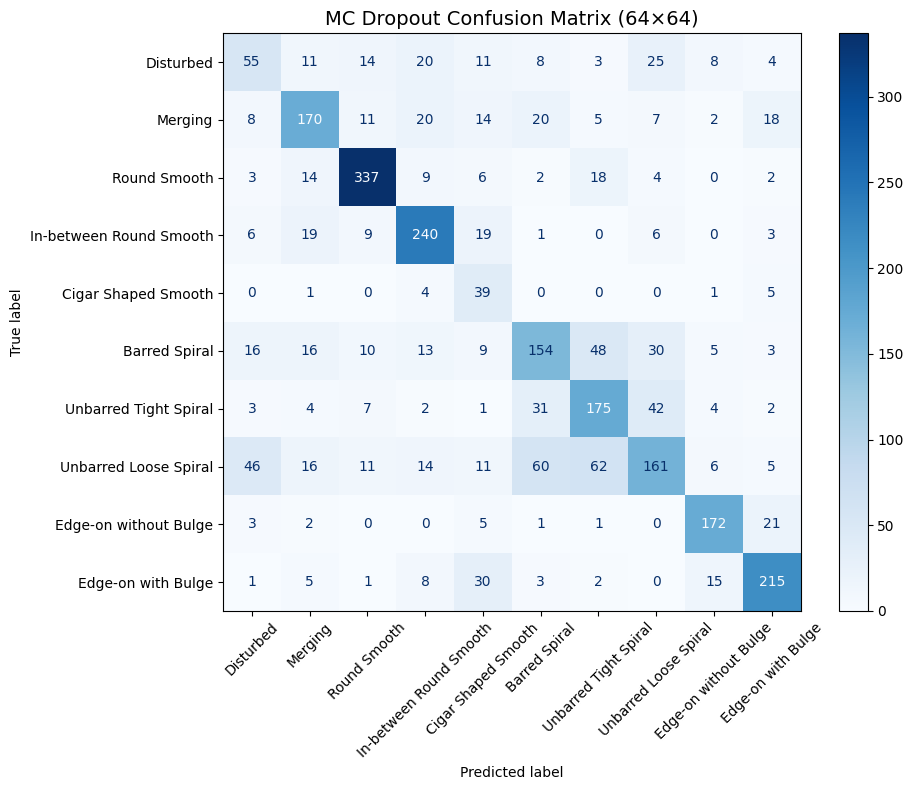

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(true_labels_vit, predicted_labels_vit)

fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
plt.title("MC Dropout Confusion Matrix (64×64)", fontsize=14)
plt.tight_layout()
plt.show()


Class 0: Accuracy = 0.346, Mean Entropy = 1.326
Class 1: Accuracy = 0.618, Mean Entropy = 1.188
Class 2: Accuracy = 0.853, Mean Entropy = 0.904
Class 3: Accuracy = 0.792, Mean Entropy = 1.164
Class 4: Accuracy = 0.780, Mean Entropy = 1.000
Class 5: Accuracy = 0.507, Mean Entropy = 1.272
Class 6: Accuracy = 0.646, Mean Entropy = 1.220
Class 7: Accuracy = 0.411, Mean Entropy = 1.357
Class 8: Accuracy = 0.839, Mean Entropy = 0.612
Class 9: Accuracy = 0.768, Mean Entropy = 0.882


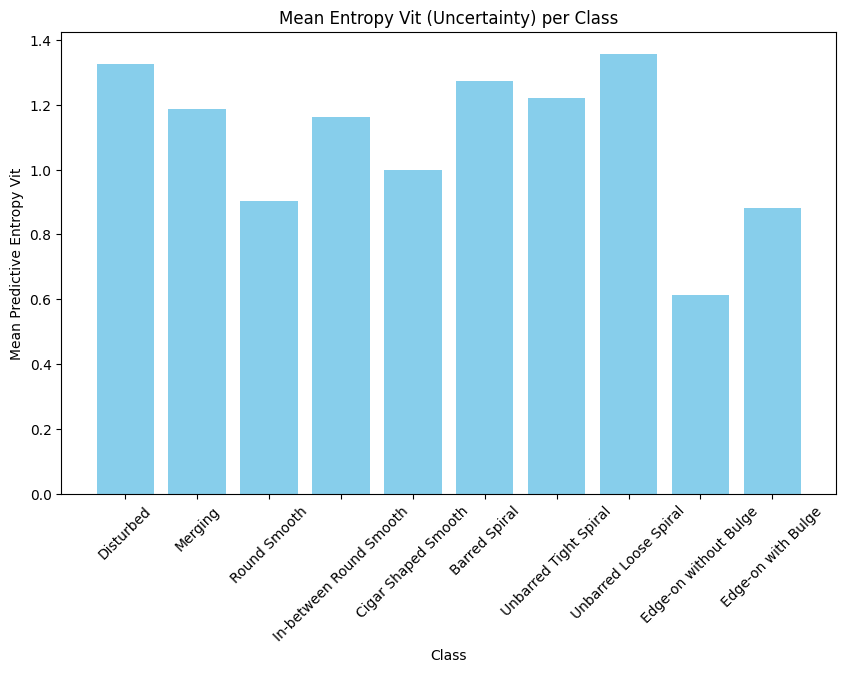

In [ ]:
# step 1d:Per-class accuracy and entropy(uncertainty) comparison
num_classes = len(np.unique(true_labels_vit))
per_class_accuracy_vit = []
mean_entropies_vit= []

# Define uncertainty using the results from mc_dropout_predict
uncertainty_vit = results_mc_vit['predictive_entropy_vit']

for class_idx in range(num_classes):
    class_mask = true_labels_vit == class_idx

    # Calculate per-class accuracy
    acc = np.mean(predicted_labels_vit[class_mask] == true_labels_vit[class_mask])
    per_class_accuracy_vit.append(acc)
    #print(f"Class {class_idx} accuracy: {acc:.3f}")

    # Calculate mean predictive entropy
    mean_entropy_vit = uncertainty_vit[class_mask].mean()
    mean_entropies_vit.append(mean_entropy_vit)
    print(f"Class {class_idx}: Accuracy = {acc:.3f}, Mean Entropy = {mean_entropy_vit:.3f}")


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies_vit, color='skyblue')
plt.xlabel('Class')
plt.ylabel('Mean Predictive Entropy Vit')
plt.title('Mean Entropy Vit (Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

In [ ]:
#  step e: Detailed Classification Report
report_vit = classification_report(true_labels_vit, predicted_labels_vit, target_names=class_names)
print(report_vit)


                         precision    recall  f1-score   support

              Disturbed       0.39      0.35      0.37       159
                Merging       0.66      0.62      0.64       275
           Round Smooth       0.84      0.85      0.85       395
In-between Round Smooth       0.73      0.79      0.76       303
    Cigar Shaped Smooth       0.27      0.78      0.40        50
          Barred Spiral       0.55      0.51      0.53       304
  Unbarred Tight Spiral       0.56      0.65      0.60       271
  Unbarred Loose Spiral       0.59      0.41      0.48       392
  Edge-on without Bulge       0.81      0.84      0.82       205
     Edge-on with Bulge       0.77      0.77      0.77       280

               accuracy                           0.65      2634
              macro avg       0.62      0.66      0.62      2634
           weighted avg       0.66      0.65      0.65      2634



In [ ]:
#2. Uncertainty Quantification Metrics(Quantify model/data uncertainty/MC Dropout)
# Predictive Entropy(Measures total uncertainty in prediction)
uncertainty_vit = results_mc_vit['predictive_entropy_vit']      # Total uncertainty(uncertainty/entropy)

# Mutual Information (Epistemic Uncertainty)
mutual_info_vit = results_mc_vit['mutual_information_vit']      # Model uncertainty/Epistemic uncertainty

# Aleatoric Uncertainty(noise inherent in input data, irreducible by more data)
aleatoric_vit = results_mc_vit['aleatoric_entropy_vit']     # Data uncertainty/Aleatoric uncertainty

print(f"\n UNCERTAINTY METRICS:")
print(f"Predictive entropy shape: {uncertainty_vit.shape}")
print(f"Mutual information shape: {mutual_info_vit.shape}")
print(f"Aleatoric uncertainty shape: {aleatoric_vit.shape}")

print(f"\n UNCERTAINTY STATISTICS:")
print(f"Average predictive entropy: {np.mean(uncertainty_vit):.4f}")
print(f"Average mutual information: {np.mean(mutual_info_vit):.4f}")
print(f"Average aleatoric uncertainty: {np.mean(aleatoric_vit):.4f}")
print(f"Uncertainty range: [{uncertainty_vit.min():.4f}, {uncertainty_vit.max():.4f}]")


 UNCERTAINTY METRICS:
Predictive entropy shape: (2634,)
Mutual information shape: (2634,)
Aleatoric uncertainty shape: (2634,)

 UNCERTAINTY STATISTICS:
Average predictive entropy: 1.1082
Average mutual information: 0.0866
Average aleatoric uncertainty: 1.0216
Uncertainty range: [0.0393, 2.1077]


Found 180 samples with high uncertainty and low confidence.


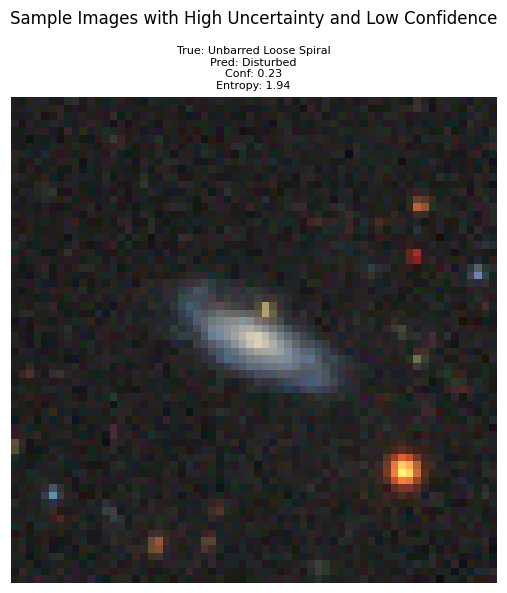

In [ ]:
# Define thresholds for high uncertainty and low confidence
# You can adjust these thresholds based on the distributions observed in the plots
uncertainty_threshold = np.percentile(results_mc_vit['predictive_entropy_vit'], 90) # e.g., top 10% most uncertain
confidence_threshold = np.percentile(confidence_scores_vit, 10) # e.g., bottom 10% least confident

# Find indices of samples meeting the criteria
high_uncertainty_low_confidence_indices = np.where(
    (results_mc_vit['predictive_entropy_vit'] > uncertainty_threshold) &
    (confidence_scores_vit < confidence_threshold)
)[0]

print(f"Found {len(high_uncertainty_low_confidence_indices)} samples with high uncertainty and low confidence.")

# Display a few sample images from these indices
num_samples_to_show = min(10, len(high_uncertainty_low_confidence_indices)) # Display up to 10 samples

if num_samples_to_show > 0:
    plt.figure(figsize=(15, 6))
    for i in range(num_samples_to_show):
        idx = high_uncertainty_low_confidence_indices[i]
        # Corrected: use 'test_images' instead of 'images_test'
        plt.imshow(test_images[idx][:, :, :3]) # Display RGB channels only for visualization
        plt.title(f"True: {class_names[true_labels_vit[idx]]}\nPred: {class_names[predicted_labels_vit[idx]]}\nConf: {confidence_scores_vit[idx]:.2f}\nEntropy: {results_mc_vit['predictive_entropy_vit'][idx]:.2f}", fontsize=8)
        plt.axis('off')
    plt.suptitle('Sample Images with High Uncertainty and Low Confidence')
    plt.tight_layout()
    plt.show()
else:
    print("No samples found meeting the criteria.")

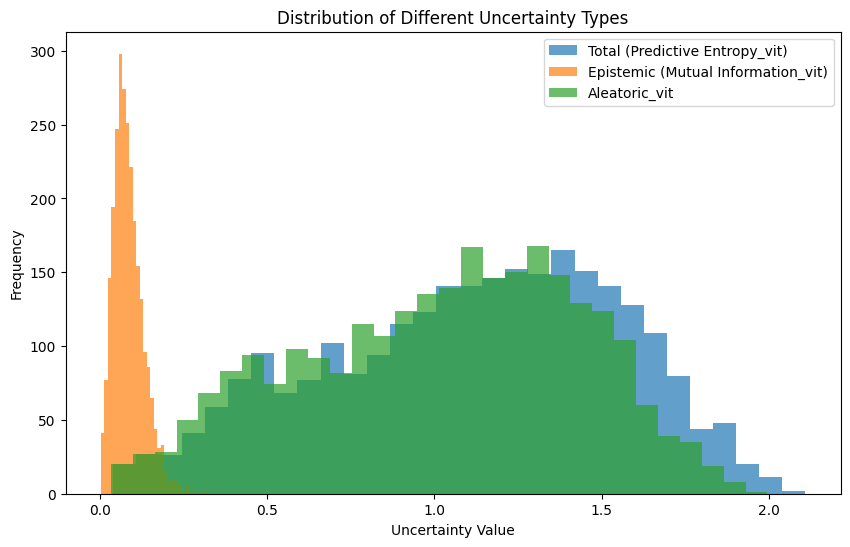

In [ ]:
# 3. Visualizations Related to Uncertainty
# Step 3a: Histogram of Uncertainty Distributions( all three)
plt.figure(figsize=(10,6))
plt.hist(uncertainty_vit, bins=30, alpha=0.7, label='Total (Predictive Entropy_vit)')
plt.hist(mutual_info_vit, bins=30, alpha=0.7, label='Epistemic (Mutual Information_vit)')
plt.hist(aleatoric_vit, bins=30, alpha=0.7, label='Aleatoric_vit')
plt.xlabel("Uncertainty Value")
plt.ylabel("Frequency")
plt.title("Distribution of Different Uncertainty Types")
plt.legend()
plt.show()

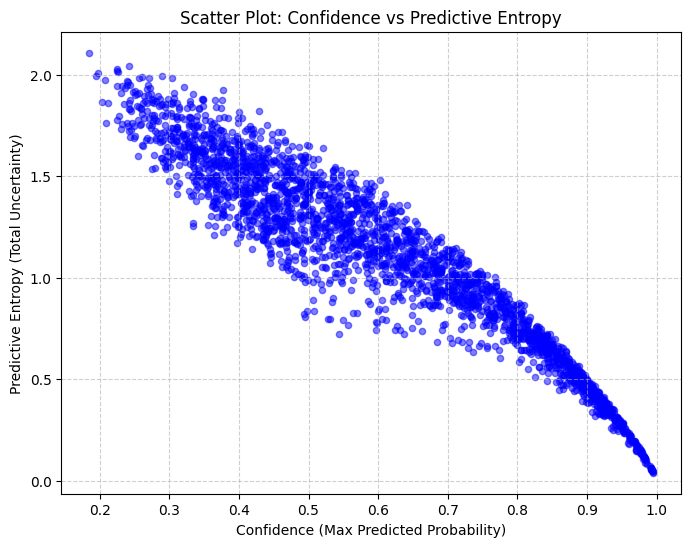

In [ ]:
# step 3b: Scatter plot: Confidence vs Predictive Entropy
plt.figure(figsize=(8,6))
plt.scatter(confidence_scores_vit, uncertainty_vit, alpha=0.5, s=20, c='blue')
plt.xlabel('Confidence (Max Predicted Probability)')
plt.ylabel('Predictive Entropy (Total Uncertainty)')
plt.title('Scatter Plot: Confidence vs Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

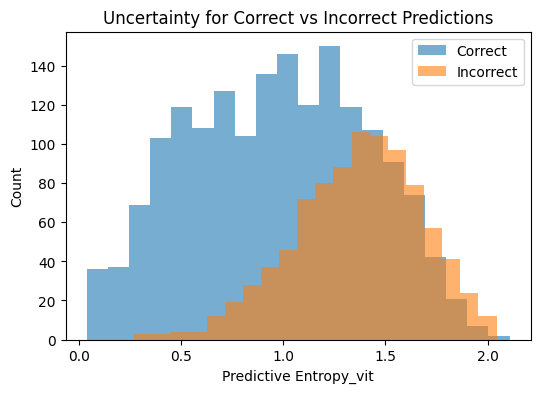

In [ ]:
# Step 3c: Compare Correct vs Incorrect Predictions
correct = (predicted_labels_vit == true_labels_vit)
plt.figure(figsize=(6,4))
plt.hist(uncertainty_vit[correct], bins=20, alpha=0.6, label='Correct')
plt.hist(uncertainty_vit[~correct], bins=20, alpha=0.6, label='Incorrect')
plt.xlabel('Predictive Entropy_vit')
plt.ylabel('Count')
plt.legend()
plt.title('Uncertainty for Correct vs Incorrect Predictions')
plt.show()

/tmp/ipython-input-83005801.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([uncertainty_vit[correct], uncertainty_vit[~correct]], labels=['Correct_vit', 'Incorrect_vit'],patch_artist=True,


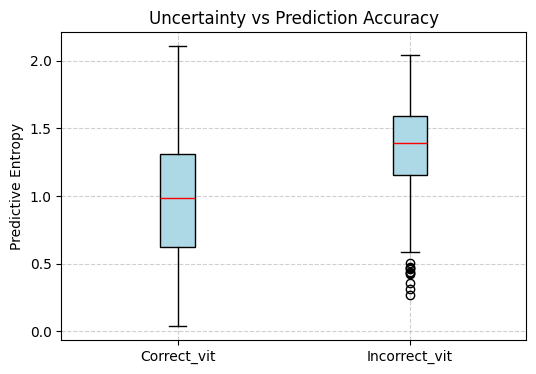

In [ ]:
# Boxplot: Uncertainty vs Correctness
correct = (predicted_labels_vit == true_labels_vit)
plt.figure(figsize=(6,4))
plt.boxplot([uncertainty_vit[correct], uncertainty_vit[~correct]], labels=['Correct_vit', 'Incorrect_vit'],patch_artist=True,
    boxprops=dict(facecolor='lightblue', color='black'),
    medianprops=dict(color='red'))
plt.title('Uncertainty vs Prediction Accuracy')
plt.ylabel('Predictive Entropy')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


predictions_all shape: (30, 2634, 10)
Average Variation Ratio: 0.15752973930650466


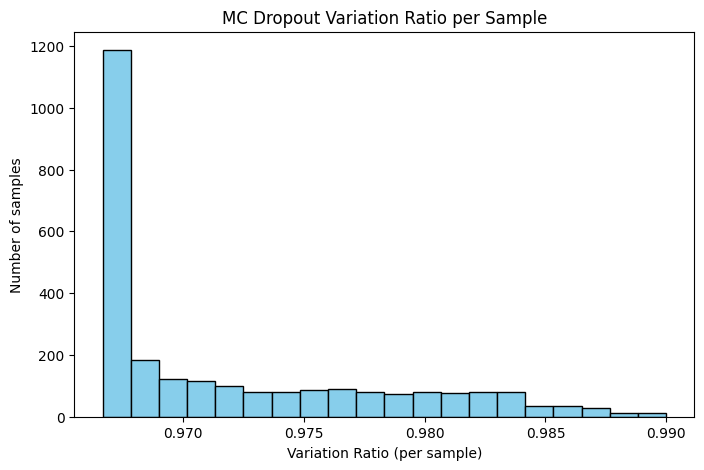

In [ ]:
# step 3d: Variation Ratio
# predictions: shape (num_mc_samples, num_test_samples, num_classes)
predictions_all = results_mc_vit['all_preds_vit']
print(f"predictions_all shape: {predictions_all.shape}")
mc_classes = np.argmax(predictions_all, axis=2)  # shape: (num_mc_samples, num_test_samples)

# For each test sample, find the most common predicted class count
mode_counts = np.apply_along_axis(lambda x: np.bincount(x, minlength=num_classes).max(), axis=0, arr=mc_classes)

variation_ratio = 1 - (mode_counts /predictions_all.shape[0])
print("Average Variation Ratio:", variation_ratio.mean())

# Compute variation ratio per test sample
num_test_samples = predictions_all.shape[1]
num_mc_samples = predictions_all.shape[0]
variation_ratio_per_sample = 1 - np.array([
    np.mean(mc_classes[:, i] == np.bincount(mc_classes[:, i]).argmax()) / num_mc_samples
    for i in range(num_test_samples)
])

# Histogram of variation ratios
plt.figure(figsize=(8,5))
plt.hist(variation_ratio_per_sample, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Variation Ratio (per sample)')
plt.ylabel('Number of samples')
plt.title('MC Dropout Variation Ratio per Sample')
plt.show()

Class 0 entropy: 1.3263547
Class 1 entropy: 1.1878976
Class 2 entropy: 0.9044888
Class 3 entropy: 1.1635714
Class 4 entropy: 0.99965227
Class 5 entropy: 1.2720973
Class 6 entropy: 1.220225
Class 7 entropy: 1.3569657
Class 8 entropy: 0.61184317
Class 9 entropy: 0.8818193


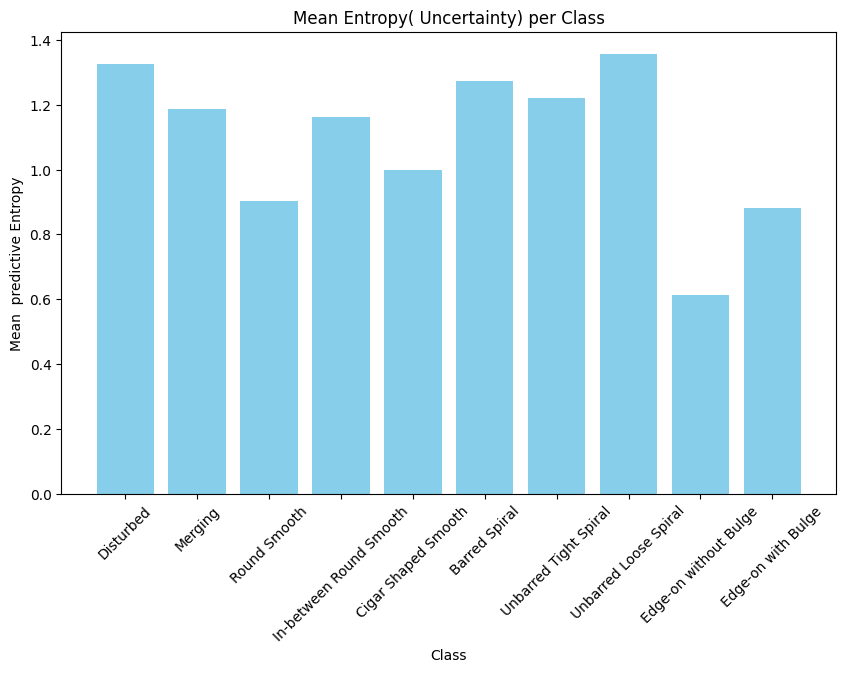

In [ ]:
# Per-Class Uncertainty(extra)

mean_entropies = []
for class_idx in range(num_classes):
    class_mask = (true_labels_vit == class_idx)
    mean_entropy = uncertainty_vit[class_mask].mean()
    mean_entropies.append(mean_entropy)
    print(f"Class {class_idx} entropy:", uncertainty_vit[class_mask].mean())


plt.figure(figsize=(10, 6))
plt.bar(range(num_classes), mean_entropies, color = 'skyblue')
plt.xlabel('Class')
plt.ylabel('Mean  predictive Entropy')
plt.title('Mean Entropy( Uncertainty) per Class')
plt.xticks(range(num_classes), class_names, rotation=45)
plt.show()

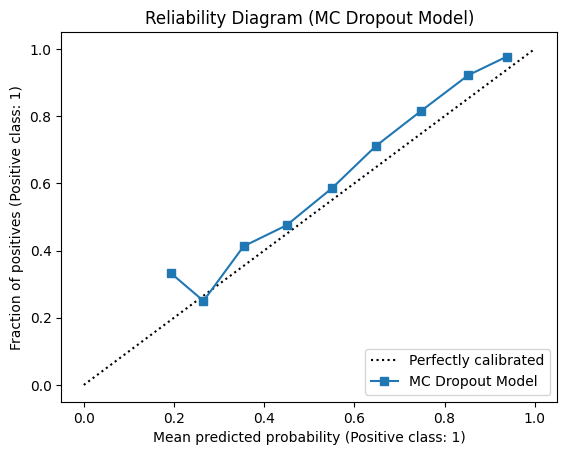

In [ ]:
# Step 4a: Reliability Diagram (Calibration Plot)
from sklearn.calibration import CalibrationDisplay
# Create true/false correctness per sample
correct = (predicted_labels_vit == true_labels_vit)

# Plot reliability diagram
disp = CalibrationDisplay.from_predictions(
    y_true=correct,
    y_prob=confidence_scores_vit,
    n_bins=10,
    strategy='uniform',
    name='MC Dropout Model'
)
plt.title("Reliability Diagram (MC Dropout Model)")
plt.show()

In [ ]:
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import label_binarize

def get_probs_and_labels_vit(model, test_ds, num_classes=10, mc_dropout=False, T=1):
    """
    Returns:
        y_true_onehot to one-hot labels
        y_prob        to predicted softmax probabilities
    """
    all_probs = []
    all_labels = []

    for images, labels in test_ds:
        labels_np = labels.numpy()
        all_labels.append(labels_np)

        # -------------------------
        # Classical prediction
        # -------------------------
        if not mc_dropout:
            logits = model(images, training=False)
            probs = tf.nn.softmax(logits, axis=-1).numpy()
            all_probs.append(probs)

        # -------------------------
        # MC Dropout prediction
        # -------------------------
        else:
            mc_probs = []
            for _ in range(T):
                logits = model(images, training=True)    # IMPORTANT
                probs  = tf.nn.softmax(logits, axis=-1).numpy()
                mc_probs.append(probs)

            # Average over T forward passes
            mc_probs = np.mean(mc_probs, axis=0)
            all_probs.append(mc_probs)

    y_true = np.concatenate(all_labels, axis=0)
    y_prob = np.concatenate(all_probs,  axis=0)

    # Convert labels → one-hot matrix (N, num_classes)
    y_true_onehot = label_binarize(y_true, classes=np.arange(num_classes))

    return y_true_onehot, y_prob


In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

def plot_roc_auc_vit(y_true_onehot, y_prob, model_name="ViT-MC"):
    num_classes = y_true_onehot.shape[1]

    fpr = {}
    tpr = {}
    roc_auc = {}

    # One-vs-rest ROC for each class
    for i in range(num_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_onehot[:, i], y_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Micro-average
    fpr["micro"], tpr["micro"], _ = roc_curve(
        y_true_onehot.ravel(), y_prob.ravel()
    )
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

    # Macro-average
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    tpr_list = []

    for i in range(num_classes):
        tpr_list.append(np.interp(fpr_grid, fpr[i], tpr[i]))

    mean_tpr = np.mean(tpr_list, axis=0)
    roc_auc["macro"] = auc(fpr_grid, mean_tpr)

    # Plot
    plt.figure(figsize=(10, 8))

    plt.plot(
        fpr_grid,
        mean_tpr,
        label=f"Macro-average ROC (AUC = {roc_auc['macro']:.4f})",
        linewidth=2,
    )

    plt.plot(
        fpr["micro"],
        tpr["micro"],
        label=f"Micro-average ROC (AUC = {roc_auc['micro']:.4f})",
        linewidth=2,
    )

    # Diagonal baseline
    plt.plot([0, 1], [0, 1], "k--", linewidth=1)

    plt.title(f"ROC–AUC Curve – {model_name}", fontsize=16)
    plt.xlabel("False Positive Rate", fontsize=14)
    plt.ylabel("True Positive Rate", fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True, linestyle="--", alpha=0.3)
    plt.show()

    return roc_auc


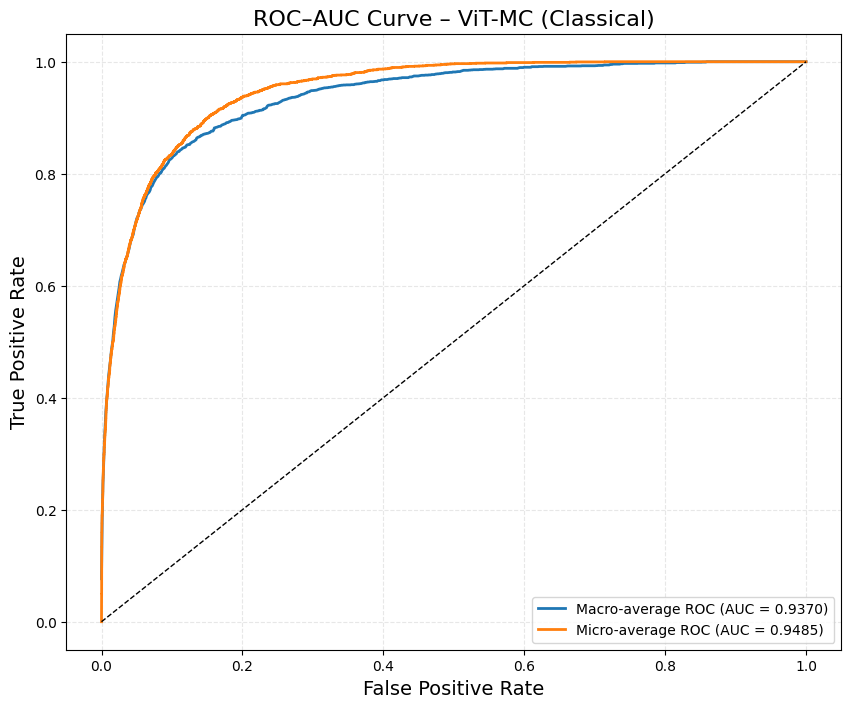

{0: np.float64(0.8390000635283654), 1: np.float64(0.9346749393040193), 2: np.float64(0.9852070035786773), 3: np.float64(0.9766470855579766), 4: np.float64(0.9754102167182663), 5: np.float64(0.8756593065281228), 6: np.float64(0.9325330705698086), 7: np.float64(0.8850681106519326), 8: np.float64(0.9898121278454448), 9: np.float64(0.9755203908241291), 'micro': np.float64(0.9485254094369516), 'macro': np.float64(0.9369633200434223)}


In [ ]:
y_true_onehot_vit, y_prob_vit = get_probs_and_labels_vit(
    model_b, test_ds, mc_dropout=False
)

roc_scores_vit = plot_roc_auc_vit(
    y_true_onehot_vit,
    y_prob_vit,
    model_name="ViT-MC (Classical)"
)

print(roc_scores_vit)


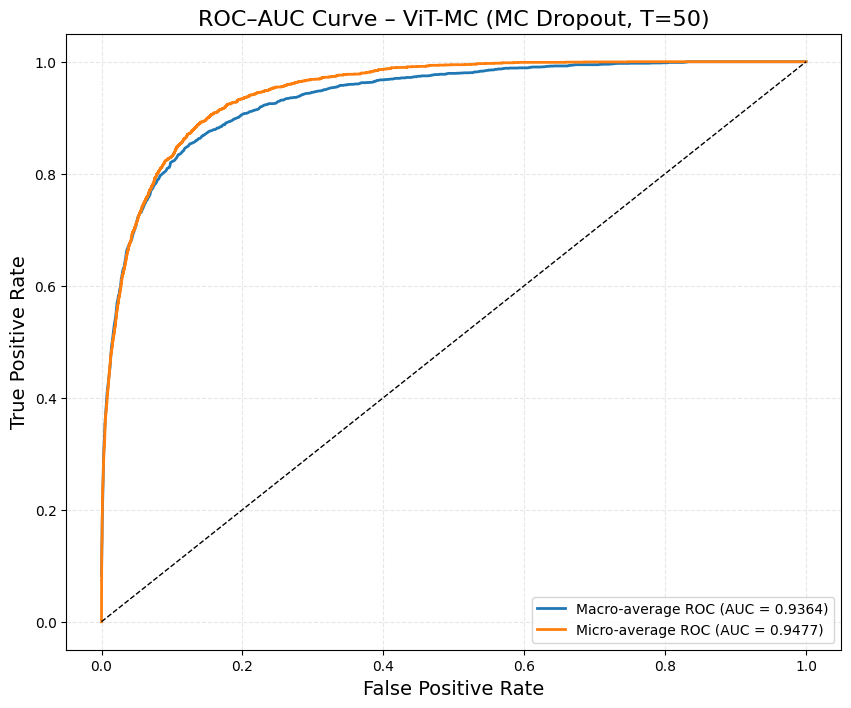

{0: np.float64(0.8443351756559304), 1: np.float64(0.9304004007861575), 2: np.float64(0.9861160893482059), 3: np.float64(0.9757168767069757), 4: np.float64(0.9743962848297213), 5: np.float64(0.872327479105489), 6: np.float64(0.9320068147782621), 7: np.float64(0.8830114784540042), 8: np.float64(0.9896735583247145), 9: np.float64(0.9757980337419591), 'micro': np.float64(0.9476508643179633), 'macro': np.float64(0.9363799509591689)}


In [ ]:
y_true_onehot_vit_mc, y_prob_vit_mc = get_probs_and_labels_vit(
    model_b, test_ds, mc_dropout=True, T=50
)

roc_scores_vit_mc = plot_roc_auc_vit(
    y_true_onehot_vit_mc,
    y_prob_vit_mc,
    model_name="ViT-MC (MC Dropout, T=50)"
)

print(roc_scores_vit_mc)


In [ ]:
# train_ds currently yields: (batch, 64, 64, 4)
train_ds_rgb = train_ds.map(
    lambda x, y: (x[..., :3], y),
    num_parallel_calls=AUTOTUNE
)

val_ds_rgb = val_ds.map(
    lambda x, y: (x[..., :3], y),
    num_parallel_calls=AUTOTUNE
)

test_ds_rgb = test_ds.map(
    lambda x, y: (x[..., :3], y),
    num_parallel_calls=AUTOTUNE
)


In [ ]:
def check_rgb_dataset(ds, name="Dataset"):
    for x, y in ds.take(1):
        print(f"--- {name} ---")
        print("Shape:", x.shape)
        print("Channels:", x.shape[-1])
        print("Label shape:", y.shape)
        print("Pixel min/max:", float(x.numpy().min()), float(x.numpy().max()))
        print()

check_rgb_dataset(train_ds, "Original Train DS")
check_rgb_dataset(train_ds_rgb, "RGB-only Train DS")
check_rgb_dataset(val_ds_rgb, "RGB-only Val DS")
check_rgb_dataset(test_ds_rgb, "RGB-only Test DS")


--- Original Train DS ---
Shape: (64, 64, 64, 4)
Channels: 4
Label shape: (64,)
Pixel min/max: 0.0 1.0

--- RGB-only Train DS ---
Shape: (64, 64, 64, 3)
Channels: 3
Label shape: (64,)
Pixel min/max: 0.0 1.0

--- RGB-only Val DS ---
Shape: (64, 64, 64, 3)
Channels: 3
Label shape: (64,)
Pixel min/max: 0.0 1.0

--- RGB-only Test DS ---
Shape: (64, 64, 64, 3)
Channels: 3
Label shape: (64,)
Pixel min/max: 0.0 1.0



In [ ]:
# Model 1:galaxynet_cnn_mc
def build_cnn_mc_rgb(input_shape=(64,64,3), num_classes=10, dropout_p=0.3):

    inputs = layers.Input(shape=input_shape)

    # Block 1
    x = layers.Conv2D(32, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(0.2)(x, training=True)

    x = layers.Conv2D(32, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 2
    x = layers.Conv2D(64, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(64, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 3
    x = layers.Conv2D(128, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(128, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Block 4
    x = layers.Conv2D(256, 3, strides=2, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    x = layers.Conv2D(256, 3, padding='same',)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.SpatialDropout2D(dropout_p)(x, training=True)

    # Global pooling
    x = layers.GlobalAveragePooling2D()(x)

    # Dense head
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_p)(x, training=True)

    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_p)(x, training=True)

    logits = layers.Dense(num_classes)(x)

    return models.Model(inputs, logits, name="build_cnn_mc_rgb")


In [ ]:
# import tensorflow as tf
# from tensorflow import keras
# from tensorflow.keras import layers

# def build_cnn_mc_rgb(input_shape=(64, 64, 3), num_classes=10, dropout_p=0.3):
#     inputs = keras.Input(shape=input_shape, name="rgb_input")

#     x = layers.Conv2D(64, (3, 3), padding="same")(inputs)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     x = layers.Conv2D(32, (3, 3), padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     x = layers.Conv2D(64, (3, 3), padding="same")(x)
#     x = layers.BatchNormalization()(x)
#     x = layers.Activation("relu")(x)
#     x = layers.MaxPooling2D((2, 2))(x)

#     x = layers.Flatten()(x)
#     x = layers.Dense(256, activation="relu")(x)
#     x = layers.Dropout(dropout_p)(x, training=True)  # MC Dropout
#     outputs = layers.Dense(num_classes)(x)  # logits

#     model = keras.Model(inputs=inputs, outputs=outputs, name="cnn_mc_rgb")
#     return model




In [ ]:
# Build Model C
model_c = build_cnn_mc_rgb(input_shape=(64,64,3), num_classes=10)

optimizer = tf.keras.optimizers.Adam(0.001)
# Compile
model_c.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)
#model_c.summary()

In [ ]:
# Callbacks
callbacks = [
    # Early stopping
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        min_delta = 0.001,
        mode ='min',
        restore_best_weights=True,
        verbose=1
    ),

    # Learning rate reduction
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-7,
        verbose=1
    ),
    # Model checkpoint
    tf.keras.callbacks.ModelCheckpoint(
        'models/cnn_mc_rgb_dropout_best.keras',
        monitor='val_accuracy',
        mode='max',
        save_best_only=True,
        save_weights_only=False,
        verbose=1
    )]

In [ ]:
history_cnn_rgb = model_c.fit(
    train_ds_rgb,
    validation_data=val_ds_rgb,
    epochs=120,
    callbacks=callbacks,  # your EarlyStopping, Checkpoint, etc.
    verbose=1
)

Epoch 1/120
289/289 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.1339 - loss: 2.2782
Epoch 1: val_accuracy improved from -inf to 0.11584, saving model to models/cnn_mc_rgb_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 36s 50ms/step - accuracy: 0.1340 - loss: 2.2781 - val_accuracy: 0.1158 - val_loss: 2.5184 - learning_rate: 0.0010
Epoch 2/120
284/289 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1635 - loss: 2.1683
Epoch 2: val_accuracy improved from 0.11584 to 0.17926, saving model to models/cnn_mc_rgb_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1635 - loss: 2.1682 - val_accuracy: 0.1793 - val_loss: 2.0837 - learning_rate: 0.0010
Epoch 3/120
284/289 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.1698 - loss: 2.1370
Epoch 3: val_accuracy improved from 0.17926 to 0.18648, saving model to models/cnn_mc_rgb_dropout_best.keras
289/289 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - accuracy: 0.1698 - loss: 2.1369 - val_accuracy: 0.1865 - val_loss: 2.0101 - learning_

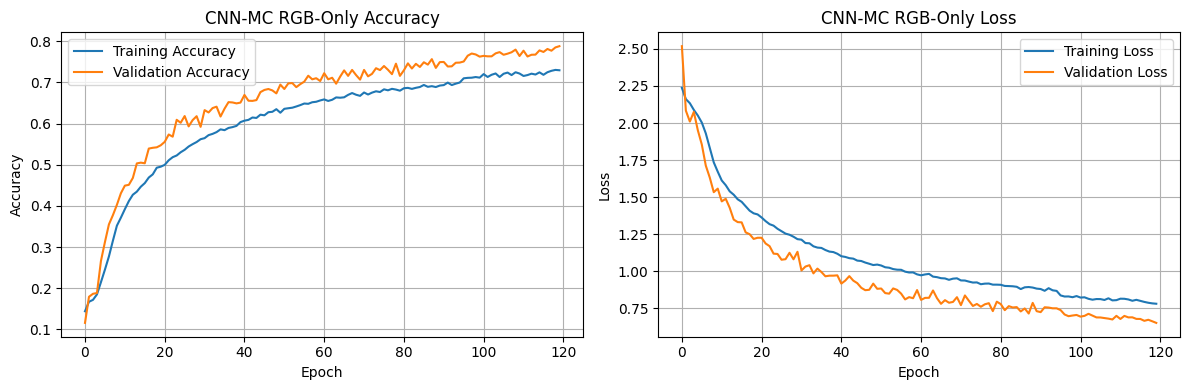

In [ ]:
import matplotlib.pyplot as plt

def plot_training_history(history, model_name="Model"): # Added model_name parameter with a default value
    """Plot training and validation metrics"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # Plot accuracy
    ax1.plot(history.history['accuracy'], label='Training Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{model_name} Accuracy') # Used f-string for dynamic title
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)
    # Plot loss
    ax2.plot(history.history['loss'], label='Training Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{model_name} Loss') # Used f-string for dynamic title
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

# Plot training history
plot_training_history(history_cnn_rgb, model_name="CNN-MC RGB-Only")